In [3]:
import requests
import time
import pandas as pd

# ================= CONFIGURAÇÕES =================
API_KEY = "cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw==" 
URL_API = "https://api-publica.datajud.cnj.jus.br/api_publica_tjce/_search"
META_PROCESSOS = 1000 

def criar_query(cursor_paginacao=None):
    """Monta o payload de busca para o ElasticSearch (DataJud - TJCE)."""
    body = {
        "size": 100,
        "query": {
            "bool": {
                "must": [
                    { "match": { "tribunal": "TJCE" } },
                    { "match": { "grau": "G1" } },
                    { "match": { "assuntos.nome": "Crimes contra a fauna" } }, 
                    # --- ALTERAÇÃO AQUI: INTERVALO DA "ERA DE OURO" DO E-SAJ ---
                    { 
                        "range": { 
                            "movimentos.dataHora": { 
                                "gte": "2015-01-01T00:00:00",
                                "lte": "2019-12-31T23:59:59"
                            } 
                        } 
                    },
                    # -----------------------------------------------------------
                    { "terms": { "movimentos.codigo": [219, 220, 221] } }
                ],
                "must_not": [ 
                    { "match_phrase": { "orgaoJulgador.nome": "TURMA" } },
                    { "match_phrase": { "orgaoJulgador.nome": "RELATOR" } }
                ]
            }
        },
        "sort": [{"@timestamp": "desc"}],
        "_source": ["numeroProcesso", "movimentos", "assuntos", "orgaoJulgador"]
    }
    
    if cursor_paginacao:
        body["search_after"] = cursor_paginacao
        
    return body

def formatar_nup(nup):
    s = str(nup).strip().zfill(20)
    return f"{s[:7]}-{s[7:9]}.{s[9:13]}.{s[13:14]}.{s[14:16]}.{s[16:20]}"

def main():
    headers = {
        "Authorization": f"APIKey {API_KEY}",
        "Content-Type": "application/json"
    }
    dados_coletados = []
    cursor = None 

    print(f"--- Coletando Processos Antigos TJCE (2015-2019) ---")

    while len(dados_coletados) < META_PROCESSOS:
        try:
            resp = requests.post(URL_API, headers=headers, json=criar_query(cursor), timeout=20)
            
            if resp.status_code != 200:
                print(f"⚠ Erro API: {resp.status_code} - Tentando novamente...")
                time.sleep(5)
                continue

            hits = resp.json().get('hits', {}).get('hits', [])
            if not hits:
                print("⏹ Fim dos resultados disponíveis na API.")
                break

            for hit in hits:
                src = hit.get('_source', {})
                orgao = src.get('orgaoJulgador', {}).get('nome', '').upper()
                nup_raw = src.get('numeroProcesso')
                
                lista_assuntos = [a['nome'] for a in src.get('assuntos', []) if 'nome' in a]
                texto_assuntos = "; ".join(lista_assuntos)

                codigos_sentenca = [219, 220, 221]
                movs = sorted(src.get('movimentos', []), key=lambda x: x.get('dataHora', ''), reverse=True)
                decisao = next((m['nome'] for m in movs if m.get('codigo') in codigos_sentenca), "Sentença Genérica")

                dados_coletados.append({
                    "NUP": nup_raw,
                    "NUP_Formatado": formatar_nup(nup_raw),
                    "Unidade": orgao,
                    "Assuntos": texto_assuntos,
                    "Decisao": decisao
                })

            cursor = hits[-1]['sort']
            print(f"Processos coletados: {len(dados_coletados)}")
            
            if len(dados_coletados) >= META_PROCESSOS:
                break
                
        except Exception as e:
            print(f"❌ Erro crítico: {e}")
            break

    # Salva o resultado
    if dados_coletados:
        nome_arquivo = "lista_tjce_fauna_antigos.csv"
        df = pd.DataFrame(dados_coletados[:META_PROCESSOS])
        df.to_csv(nome_arquivo, index=False, sep=';', encoding='utf-8-sig')
        print(f"\n✅ Arquivo '{nome_arquivo}' gerado com sucesso!")
    else:
        print("\n⚠ Nenhum dado encontrado neste período.")

if __name__ == "__main__":
    main()

--- Coletando Processos Antigos TJCE (2015-2019) ---
Processos coletados: 100
Processos coletados: 200
Processos coletados: 300
Processos coletados: 400
Processos coletados: 500
Processos coletados: 600
Processos coletados: 700
Processos coletados: 800
Processos coletados: 900
Processos coletados: 1000

✅ Arquivo 'lista_tjce_fauna_antigos.csv' gerado com sucesso!


In [7]:
!pip install -U selenium webdriver-manager

In [12]:
import os
import time
import re
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# ================= CONFIGURAÇÕES =================
ARQUIVO_ENTRADA = "lista_tjce_fauna_antigos.csv" # <--- Alterado para a lista TJCE
PASTA_DESTINO = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen" 
URL_ESAJ = "https://esaj.tjce.jus.br/cpopg/open.do" # <--- Alterado para TJCE

if not os.path.exists(PASTA_DESTINO):
    os.makedirs(PASTA_DESTINO)

def configurar_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--ignore-certificate-errors")
    options.add_argument("--start-maximized")
    options.add_argument("--disable-gpu")
    
    prefs = {
        "download.default_directory": PASTA_DESTINO,
        "download.prompt_for_download": False,
        "download.directory_upgrade": True,
        "plugins.always_open_pdf_externally": False, 
        "safebrowsing.enabled": True
    }
    options.add_experimental_option("prefs", prefs)
    
    return webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

def formatar_nup(nup):
    clean = re.sub(r'\D', '', str(nup)).zfill(20)
    return {
        "num_unificado": f"{clean[0:7]}-{clean[7:9]}.{clean[9:13]}",
        "foro": clean[16:20]
    }

def expandir_movimentacoes(driver):
    """
    Função Alterada: Adicionado loop para clicar em 'Mais' recursivamente
    até expandir o terceiro, quarto, etc.
    """
    try:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        
        # 1. Tenta o botão principal "Ver todas as movimentações"
        try:
            link_mov = driver.find_element(By.ID, "linkMovimentacoes")
            if link_mov.is_displayed():
                driver.execute_script("arguments[0].click();", link_mov)
                time.sleep(1)
        except: pass

        # 2. Loop insistente para clicar em todos os "Mais..." (resolvendo o problema do 3º nível)
        tentativas = 0
        while tentativas < 5: # Tenta até 5 níveis de profundidade
            clicou_algo = False
            links = driver.find_elements(By.TAG_NAME, "a")
            for link in links:
                if "Mais" in link.text and link.is_displayed():
                    try:
                        driver.execute_script("arguments[0].click();", link)
                        time.sleep(0.5) # Pausa curta para expandir
                        clicou_algo = True
                    except: pass
            
            # Se não achou nenhum "Mais" pra clicar nesta rodada, para o loop
            if not clicou_algo:
                break
                
            time.sleep(1) # Espera o novo conteúdo carregar antes de procurar o próximo "Mais"
            tentativas += 1

    except: pass

def esperar_novo_arquivo_e_renomear(pasta, arquivos_antes, nup_formatado, timeout=60):
    print("   > Aguardando novo arquivo...", end="\r")
    fim = time.time() + timeout
    
    while time.time() < fim:
        try:
            arquivos_agora = set(os.listdir(pasta))
            novos = arquivos_agora - arquivos_antes
            novos_pdfs = [f for f in novos if f.endswith(".pdf")]
            
            if novos_pdfs:
                nome_arquivo_novo = novos_pdfs[0]
                caminho_origem = os.path.join(pasta, nome_arquivo_novo)
                
                time.sleep(1) 
                
                caminho_final = os.path.join(pasta, f"{nup_formatado}.pdf")
                
                if os.path.exists(caminho_final):
                    try: os.remove(caminho_final)
                    except: pass
                
                tentativas = 0
                while tentativas < 5:
                    try:
                        os.rename(caminho_origem, caminho_final)
                        return True
                    except PermissionError:
                        time.sleep(1)
                        tentativas += 1
                    except Exception:
                        return False
        except: pass
                    
        time.sleep(1)
        
    return False

def tentar_clicar_botoes(driver):
    seletores = [
        (By.ID, "download"), 
        (By.CSS_SELECTOR, "button[title='Baixar']"),
        (By.CSS_SELECTOR, "button[title='Download']"),
        (By.ID, "botaoSalvar"),
        (By.CSS_SELECTOR, ".toolbarButton.download"),
        (By.ID, "secondaryDownload")
    ]
    
    for by, selector in seletores:
        try:
            botao = driver.find_element(by, selector)
            if botao.is_displayed():
                driver.execute_script("arguments[0].click();", botao)
                return True
        except: continue
    return False

def clicar_botao_baixar_popup(driver, wait):
    try:
        if tentar_clicar_botoes(driver): return True
            
        frames = driver.find_elements(By.TAG_NAME, "iframe")
        for frame in frames:
            try:
                driver.switch_to.frame(frame)
                if tentar_clicar_botoes(driver):
                    driver.switch_to.default_content()
                    return True
                
                subframes = driver.find_elements(By.TAG_NAME, "iframe")
                for subframe in subframes:
                    driver.switch_to.frame(subframe)
                    if tentar_clicar_botoes(driver):
                        driver.switch_to.default_content()
                        return True
                    driver.switch_to.parent_frame()

                driver.switch_to.default_content()
            except:
                driver.switch_to.default_content()
    except: pass
    return False

def processar_sentenca(driver, wait, nup_formatado):
    """
    Retorna uma TUPLA: (status, texto_da_movimentacao)
    """
    expandir_movimentacoes(driver)
    
    # Mantidos os gatilhos originais conforme solicitado
    gatilhos = ["julgado improcedente", "julgado procedente", "sentença", "extinguindo", "mérito"]
    
    try:
        wait.until(EC.presence_of_element_located((By.ID, "tabelaTodasMovimentacoes")))
        linhas = driver.find_elements(By.CSS_SELECTOR, "#tabelaTodasMovimentacoes tr")
        janela_principal = driver.current_window_handle
        
        for linha in linhas:
            texto_linha = linha.text
            texto_lower = texto_linha.lower()
            
            if any(g in texto_lower for g in gatilhos):
                # --- CAPTURA O TEXTO AQUI ---
                # Remove quebras de linha para ficar numa linha só no Excel
                teor_movimentacao = texto_linha.replace("\n", " || ").strip()
                
                try:
                    links = linha.find_elements(By.TAG_NAME, "a")
                    for link in links:
                        if link.is_displayed():
                            
                            arquivos_antes = set(os.listdir(PASTA_DESTINO))

                            driver.execute_script("arguments[0].click();", link)
                            wait.until(EC.number_of_windows_to_be(2))
                            
                            janelas = driver.window_handles
                            driver.switch_to.window(janelas[-1])
                            time.sleep(3) 
                            
                            clicou = clicar_botao_baixar_popup(driver, WebDriverWait(driver, 5))
                            
                            status = "Erro Clique"
                            if clicou:
                                if esperar_novo_arquivo_e_renomear(PASTA_DESTINO, arquivos_antes, nup_formatado):
                                    status = "Sucesso"
                                else:
                                    status = "Erro: Arquivo não apareceu"
                            
                            driver.close()
                            driver.switch_to.window(janela_principal)
                            
                            # Retorna o Status E o Texto capturado
                            return status, teor_movimentacao

                except Exception as e:
                    print(f"   > Erro linha: {e}")
                    if len(driver.window_handles) > 1:
                        driver.close()
                        driver.switch_to.window(janela_principal)
                    continue

    except Exception as e:
        return f"Erro Geral: {str(e)}", ""
        
    return "Documento não encontrado", ""

def main():
    if not os.path.exists(ARQUIVO_ENTRADA):
        return print(f"❌ Arquivo '{ARQUIVO_ENTRADA}' não encontrado.")

    print(f"--- Iniciando Robô TJCE (Versão Expandir Tudo) ---")
    print(f"📂 Pasta: {PASTA_DESTINO}")
    
    df = pd.read_csv(ARQUIVO_ENTRADA, sep=';', encoding='utf-8-sig')
    
    # === TESTE COM 10 ===
    #df = df.head(10)
    # ====================

    if 'Status_Download' not in df.columns: df['Status_Download'] = None
    if 'Magistrado_Scraping' not in df.columns: df['Magistrado_Scraping'] = None
    # Nova coluna para o texto da tabela
    if 'Teor_Movimentacao' not in df.columns: df['Teor_Movimentacao'] = None

    driver = configurar_driver()
    wait = WebDriverWait(driver, 20)

    try:
        for index, row in df.iterrows():
            nup = row.get('NUP_Formatado', row.get('NUP', '')) # Ajustado para pegar NUP ou NUP_Formatado
            print(f"\n[{index+1}/{len(df)}] Processando: {nup}")

            try:
                driver.get(URL_ESAJ)
                dados = formatar_nup(nup)

                driver.execute_script("arguments[0].value = arguments[1];", wait.until(EC.presence_of_element_located((By.ID, "numeroDigitoAnoUnificado"))), dados['num_unificado'])
                driver.execute_script("arguments[0].value = arguments[1];", driver.find_element(By.ID, "foroNumeroUnificado"), dados['foro'])
                driver.find_element(By.ID, "botaoConsultarProcessos").click()

                wait.until(lambda d: d.find_elements(By.CLASS_NAME, "secaoFormBody") or d.find_elements(By.ID, "mensagemRetorno") or d.find_elements(By.ID, "senhaProcesso") or d.find_elements(By.ID, "processoSelecionado"))

                if driver.find_elements(By.ID, "senhaProcesso") and driver.find_elements(By.ID, "senhaProcesso")[0].is_displayed():
                    print("   > 🔒 Segredo")
                    continue
                if driver.find_elements(By.ID, "mensagemRetorno") and "não existem" in driver.find_elements(By.ID, "mensagemRetorno")[0].text.lower():
                    print("   > ❌ Não encontrado")
                    continue
                if driver.find_elements(By.ID, "processoSelecionado"):
                    driver.find_elements(By.ID, "processoSelecionado")[0].click()
                    driver.find_element(By.ID, "botaoEnviar").click()
                    time.sleep(1)

                try:
                    juiz = driver.find_element(By.ID, "juizProcesso").text.strip()
                    df.at[index, 'Magistrado_Scraping'] = juiz
                except: pass

                # Chama a função que retorna STATUS e TEXTO
                status, texto_mov = processar_sentenca(driver, wait, nup)
                
                if status == "Sucesso":
                    print(f"   > 💾 PDF Salvo!")
                    if texto_mov:
                        print(f"   > 📜 Texto: {texto_mov[:50]}...")
                else:
                    print(f"   > ⚠ {status}")

                df.at[index, 'Status_Download'] = status
                df.at[index, 'Teor_Movimentacao'] = texto_mov

            except Exception as e:
                print(f"   > ⚠ Erro crítico: {e}")
                
    except KeyboardInterrupt:
        print("\n⏹ Parado.")
    finally:
        driver.quit()
        df.to_csv(os.path.join(PASTA_DESTINO, "log_downloads_tjce.csv"), index=False, sep=';', encoding='utf-8-sig')
        print(f"\n✅ Finalizado! Log salvo com textos.")

if __name__ == "__main__":
    main()

--- Iniciando Robô TJCE (Versão Expandir Tudo) ---
📂 Pasta: C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen

[1/1000] Processando: 0001494-18.2007.8.06.0128
   > ⚠ Documento não encontrado

[2/1000] Processando: 0111667-87.2016.8.06.0001
   > Erro linha: Message: 

   > Erro linha: Message: 

   > 💾 PDF Salvo!vo arquivo...
   > 📜 Texto: 03/03/2021 Julgado procedente o pedido || Posto is...

[3/1000] Processando: 0004685-26.2017.8.06.0159
   > 💾 PDF Salvo!vo arquivo...
   > 📜 Texto: 23/06/2022 Julgado procedente em parte do pedido |...

[4/1000] Processando: 0005923-12.2000.8.06.0051
   > ⚠ Documento não encontrado

[5/1000] Processando: 0000728-46.2019.8.06.0159
   > 💾 PDF Salvo!vo arquivo...
   > 📜 Texto: 12/06/2023 Proferido despacho de mero expediente |...

[6/1000] Processando: 0004206-67.2016.8.06.0159
   > 💾 PDF Salvo!vo arquivo...
   > 📜 Texto: 16/08/2023 Decisão de Saneamento e Organização || ...

[7/1000] Processando: 0001312-52.201

In [14]:
!pip install -U pypdf pdfplumber pandas

In [1]:
import os
import re
import pandas as pd
import pdfplumber

# =================== CAMINHOS (SEUS) ===================
PASTA_PDFS = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"
CSV_LOG = os.path.join(PASTA_PDFS, "log_downloads_tjce.csv")

# Saída nova (para não sobrescrever)
SAIDA = os.path.join(PASTA_PDFS, "log_downloads_tjce_com_magistrado_assinatura_pdf.csv")
# =======================================================

# -------- utilitários --------
def normalizar_espacos(s: str) -> str:
    return re.sub(r"\s+", " ", s or "").strip()

def limpar_nome(nome: str) -> str:
    nome = normalizar_espacos(nome)
    # Remove Dr/Dra no início, se houver
    nome = re.sub(r"^(?:Dr\.?|Dra\.?)\s+", "", nome, flags=re.IGNORECASE)
    # Remove parênteses finais
    nome = re.sub(r"\s*\(.*?\)\s*$", "", nome)
    # Heurísticas simples de validade
    if len(nome) < 6:
        return ""
    # Evita pegar “PODER JUDICIÁRIO...” etc.
    if re.search(r"\bPODER\b|\bTRIBUNAL\b|\bCOMARCA\b", nome, flags=re.IGNORECASE):
        return ""
    # Evita pegar linhas com números
    if re.search(r"\d", nome):
        return ""
    # Evita pegar linha toda em maiúsculas muito “genérica” (opcional)
    return nome

def extrair_texto_paginas_finais(caminho_pdf: str, ultimas_paginas: int = 2) -> list[str]:
    """
    Retorna uma lista de textos, um por página, apenas das últimas N páginas,
    preservando a separação por página (isso é crucial para evitar mistura).
    """
    textos = []
    try:
        with pdfplumber.open(caminho_pdf) as pdf:
            n = len(pdf.pages)
            start = max(0, n - ultimas_paginas)
            for i in range(start, n):
                # layout=True costuma ajudar em PDFs jurídicos
                t = pdf.pages[i].extract_text(layout=True) or ""
                t = t.strip()
                textos.append(t)
    except Exception:
        return []
    return textos

# -------- EXTRAÇÃO “ASSINATURA” (PRIORIDADE TOTAL) --------
def extrair_magistrado_assinatura_por_pagina(texto_pagina: str) -> str:
    """
    Extrai o nome associado à assinatura, procurando padrões próximos ao cargo
    (Juiz/Juíza de Direito etc.). Retorna o ÚLTIMO match válido da página.
    """
    if not texto_pagina:
        return ""

    t = texto_pagina

    # Padrões: nome + (linha seguinte ou mesma linha) + cargo
    # Vamos capturar de modo "guloso controlado" e depois escolher o ÚLTIMO match.
    padroes = [
        # Nome em uma linha, cargo na linha seguinte
        r"(?im)(?:^|\n)\s*([A-ZÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ][A-Za-zÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ'\-\. ]{8,80})\s*(?:\n|\r\n)\s*(Ju[ií]z(?:a)? de Direito)\b",
        r"(?im)(?:^|\n)\s*([A-ZÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ][A-Za-zÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ'\-\. ]{8,80})\s*(?:\n|\r\n)\s*(Ju[ií]z(?:a)? Substitut[oa] de Direito)\b",
        r"(?im)(?:^|\n)\s*([A-ZÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ][A-Za-zÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ'\-\. ]{8,80})\s*(?:\n|\r\n)\s*(Desembargador(?:a)?)\b",

        # Nome e cargo na mesma linha (às vezes acontece por extração “colada”)
        r"(?im)(?:^|\n)\s*([A-ZÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ][A-Za-zÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ'\-\. ]{8,80})\s*[-–—,]*\s*(Ju[ií]z(?:a)? de Direito)\b",
        r"(?im)(?:^|\n)\s*([A-ZÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ][A-Za-zÁÀÂÃÉÈÊÍÌÎÓÒÔÕÚÙÛÇ'\-\. ]{8,80})\s*[-–—,]*\s*(Ju[ií]z(?:a)? Substitut[oa] de Direito)\b",
    ]

    candidatos = []
    for p in padroes:
        for m in re.finditer(p, t):
            nome = limpar_nome(m.group(1))
            if nome:
                candidatos.append(nome)

    # Queremos o ÚLTIMO candidato da página (mais próximo do rodapé/assinatura)
    if candidatos:
        return candidatos[-1]

    # Fallback: se aparecer “Juiz/Juíza de Direito”,
    # pegar a linha imediatamente anterior (última ocorrência).
    linhas = [normalizar_espacos(x) for x in t.splitlines() if normalizar_espacos(x)]
    idxs = [i for i, ln in enumerate(linhas) if re.search(r"\bJu[ií]z(?:a)? de Direito\b", ln, flags=re.IGNORECASE)]
    if idxs:
        i = idxs[-1]
        if i > 0:
            cand = limpar_nome(linhas[i - 1])
            if cand:
                return cand

    return ""

def extrair_magistrado_assinatura_pdf(caminho_pdf: str, ultimas_paginas: int = 2) -> tuple[str, str]:
    """
    Procura a assinatura começando da ÚLTIMA página para trás.
    Retorna (nome, observação).
    """
    textos_paginas = extrair_texto_paginas_finais(caminho_pdf, ultimas_paginas=ultimas_paginas)
    if not textos_paginas or all(not t.strip() for t in textos_paginas):
        return "", "Sem texto extraível (PDF imagem/OCR necessário)"

    # Itera de trás pra frente: última página primeiro
    for idx_reverso, texto in enumerate(reversed(textos_paginas), start=1):
        nome = extrair_magistrado_assinatura_por_pagina(texto)
        if nome:
            # indica em qual “página final” encontrou (1 = última, 2 = penúltima, etc.)
            return nome, f"OK (assinatura nas últimas páginas; back={idx_reverso})"

    return "", "Texto extraído, mas assinatura não localizada nas últimas páginas"

# =================== EXECUÇÃO ===================
if not os.path.exists(CSV_LOG):
    raise FileNotFoundError(f"Não achei o CSV em: {CSV_LOG}")

df = pd.read_csv(CSV_LOG, sep=";", encoding="utf-8-sig")

# Colunas novas (não destrói nada anterior)
if "Magistrado_PDF_Assinatura" not in df.columns:
    df["Magistrado_PDF_Assinatura"] = ""
if "Obs_Magistrado_PDF_Assinatura" not in df.columns:
    df["Obs_Magistrado_PDF_Assinatura"] = ""

# (Opcional) Consolidado: prioriza assinatura do PDF, senão mantém scraping anterior
if "Magistrado_Consolidado" not in df.columns:
    df["Magistrado_Consolidado"] = ""

total = len(df)
encontrados = 0
sem_texto = 0
pdf_nao_encontrado = 0
assinatura_nao_localizada = 0

for idx, row in df.iterrows():
    nup_fmt = str(row.get("NUP_Formatado", "")).strip()
    nup_raw = str(row.get("NUP", "")).strip()
    candidato = nup_fmt if nup_fmt and nup_fmt.lower() != "nan" else nup_raw

    if not candidato or candidato.lower() == "nan":
        df.at[idx, "Obs_Magistrado_PDF_Assinatura"] = "NUP ausente"
        continue

    caminho_pdf = os.path.join(PASTA_PDFS, f"{candidato}.pdf")
    if not os.path.exists(caminho_pdf):
        df.at[idx, "Obs_Magistrado_PDF_Assinatura"] = "PDF não encontrado na pasta"
        pdf_nao_encontrado += 1
        continue

    nome, obs = extrair_magistrado_assinatura_pdf(caminho_pdf, ultimas_paginas=2)
    df.at[idx, "Magistrado_PDF_Assinatura"] = nome
    df.at[idx, "Obs_Magistrado_PDF_Assinatura"] = obs

    if obs.startswith("OK"):
        encontrados += 1
    elif "Sem texto extraível" in obs:
        sem_texto += 1
    elif "assinatura não localizada" in obs.lower():
        assinatura_nao_localizada += 1

    # Consolidação (opcional):
    # prioridade: assinatura do PDF; fallback: Magistrado_Scraping; senão Magistrado_PDF antigo
    if nome:
        df.at[idx, "Magistrado_Consolidado"] = nome
    else:
        ms = str(row.get("Magistrado_Scraping", "")).strip()
        mp = str(row.get("Magistrado_PDF", "")).strip()
        if ms and ms.lower() != "nan":
            df.at[idx, "Magistrado_Consolidado"] = ms
        elif mp and mp.lower() != "nan":
            df.at[idx, "Magistrado_Consolidado"] = mp
        else:
            df.at[idx, "Magistrado_Consolidado"] = ""

df.to_csv(SAIDA, index=False, sep=";", encoding="utf-8-sig")

print("✅ Concluído!")
print("Arquivo de saída:", SAIDA)
print(f"Total linhas: {total}")
print(f"Encontrados (assinatura PDF): {encontrados}")
print(f"PDF não encontrado: {pdf_nao_encontrado}")
print(f"Sem texto extraível: {sem_texto}")
print(f"Assinatura não localizada: {assinatura_nao_localizada}")

✅ Concluído!
Arquivo de saída: C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\log_downloads_tjce_com_magistrado_assinatura_pdf.csv
Total linhas: 1000
Encontrados (assinatura PDF): 525
PDF não encontrado: 77
Sem texto extraível: 0
Assinatura não localizada: 398


# Projeto: Análise de Sentimento em Sentenças Judiciais por Gênero do Magistrado

## 1. Pergunta de Pesquisa

Este trabalho investiga a seguinte pergunta de pesquisa:

**Há diferença de sentimento na redação das sentenças judiciais entre juízes e juízas no Brasil?**

A motivação da pesquisa está ancorada em debates contemporâneos sobre neutralidade judicial, possíveis vieses institucionais e diferenças estilísticas na redação das decisões judiciais. No contexto do sistema de justiça criminal, compreender eventuais diferenças associadas ao gênero do magistrado contribui para discussões mais amplas sobre igualdade institucional, transparência e formulação de políticas públicas baseadas em evidências.

---

## 2. Delineamento Geral do Estudo

O estudo foi estruturado em quatro grandes etapas metodológicas:

1. Coleta automatizada de processos judiciais;
2. Extração e enriquecimento de dados textuais e metadados;
3. Identificação do magistrado responsável pela decisão e inferência de gênero;
4. Aplicação de análise de sentimento às sentenças judiciais.

Este documento descreve detalhadamente as etapas de coleta, preparação e enriquecimento dos dados, que fundamentam as análises estatísticas e de Processamento de Linguagem Natural (PLN) realizadas posteriormente.

---

## 3. Tribunal e Recorte Empírico

- **Tribunal:** Tribunal de Justiça do Estado do Ceará (TJCE)  
- **Instância:** 1º Grau  
- **Período temporal:** 2015 a 2019  
- **Fonte primária:** API Pública do CNJ – DataJud  
- **Fonte documental complementar:** Portal e-SAJ do TJCE  

O TJCE foi selecionado por apresentar integração com a API DataJud, ampla disponibilidade pública de decisões judiciais e relativa padronização documental, o que favorece a aplicação de métodos computacionais de coleta e análise textual.

---

## 4. Coleta de Dados

### 4.1 Uso da API DataJud (CNJ)

A primeira etapa consistiu na consulta à API Pública do DataJud, que indexa processos judiciais brasileiros em estrutura compatível com ElasticSearch. Foram aplicados os seguintes filtros principais:

- Tribunal: TJCE  
- Grau: 1º Grau  
- Assunto: **Crimes contra a fauna**  
- Período das movimentações processuais: 2015 a 2019  

A consulta foi paginada por meio do mecanismo `search_after`, respeitando limites de requisição, boas práticas de uso da API e princípios de reprodutibilidade.

Como resultado, foi gerado o arquivo:

contendo **1.000 processos judiciais únicos**, já filtrados tematicamente.

**Observação metodológica:**  
O recorte temático foi realizado exclusivamente nesta etapa de API. As fases posteriores apenas processam os processos previamente selecionados, sem aplicação de novos filtros materiais sobre o conteúdo das decisões.

---

### 4.2 Web Scraping no Portal e-SAJ (TJCE)

Na segunda etapa, foi implementado web scraping utilizando Selenium para acessar o portal e-SAJ do TJCE, com os seguintes objetivos:

- Consultar cada processo a partir do Número Único de Processo (NUP);
- Expandir todas as movimentações processuais disponíveis;
- Identificar decisões relevantes (sentenças, decisões de mérito e decisões terminativas);
- Baixar automaticamente os arquivos PDF das decisões;
- Registrar logs detalhados do processo de coleta.

Foram adotados cuidados técnicos relevantes, tais como:

- Uso de esperas explícitas (`WebDriverWait`);
- Controle de múltiplas janelas e iframes;
- Detecção de processos em segredo de justiça;
- Tratamento de erros sem interrupção do fluxo;
- Registro estruturado de status e mensagens.

Ao final dessa etapa, foi gerado o arquivo:



log_downloads_tjce.csv

contendo **1.000 processos judiciais únicos**, já filtrados tematicamente.

**Observação metodológica:**  
O recorte temático foi realizado exclusivamente nesta etapa de API. As fases posteriores apenas processam os processos previamente selecionados, sem aplicação de novos filtros materiais sobre o conteúdo das decisões.

---

## 5. Extração do Magistrado a partir da Assinatura do PDF

### 5.1 Justificativa Metodológica

Durante a análise exploratória dos dados, observou-se que o nome do magistrado nem sempre está disponível de forma estruturada no HTML do portal e-SAJ. Em muitos casos, a única identificação confiável do julgador encontra-se na **assinatura ao final do PDF da decisão**.

Verificou-se também que abordagens mais permissivas, baseadas em menções ao longo do texto, produziam falsos positivos, capturando nomes de magistrados citados incidentalmente, relatores de instâncias superiores ou autoridades mencionadas no corpo da decisão.

Diante disso, optou-se por uma estratégia metodologicamente mais conservadora, priorizando a **precisão da identificação** em detrimento da cobertura total da amostra.

---

### 5.2 Estratégia Técnica

Foi desenvolvido um script em Python que:

- Percorre exclusivamente as últimas páginas dos PDFs (onde usualmente se localiza a assinatura);
- Extrai o texto preservando a segmentação por página;
- Aplica expressões regulares específicas para padrões de assinatura, tais como:
  - Nome próprio seguido de “Juiz de Direito” ou “Juíza de Direito”;
- Prioriza a última ocorrência válida do padrão no documento;
- Normaliza o nome extraído;
- Registra explicitamente os casos em que a assinatura não pôde ser localizada.

Essa estratégia reduz significativamente o risco de atribuição incorreta da decisão a magistrados que não foram os responsáveis diretos pelo julgamento analisado.

---

### 5.3 Resultados da Extração

Após a execução completa do script de extração por assinatura, obteve-se:

- Total de processos analisados: **1.000**
- Magistrados identificados via assinatura do PDF: **525**
- PDFs sem texto extraível: **0**
- PDFs não encontrados na pasta: **77**
- PDFs com texto, mas sem assinatura localizada: **398**

O arquivo final gerado foi:

log_downloads_tjce_com_magistrado_assinatura_pdf.csv

Apesar da redução do corpus em relação a abordagens anteriores, a amostra final **supera o mínimo de 500 sentenças exigido no trabalho**, garantindo elevada confiabilidade na identificação do magistrado responsável pela decisão.

---

## 6. Considerações Metodológicas Importantes

### 6.1 Precisão versus Cobertura

A opção por identificar apenas magistrados cuja assinatura foi explicitamente localizada no PDF representa uma escolha metodológica deliberada. Casos ambíguos ou sem identificação clara foram excluídos de forma transparente, priorizando a validade interna do estudo.

### 6.2 Divergência de Assuntos entre API e PDF

Observou-se que o assunto descrito no PDF pode divergir daquele indexado na API DataJud. Essa divergência não invalida o recorte empírico, pois a seleção temática foi realizada de forma sistemática e reproduzível na etapa inicial de coleta.

### 6.3 Ética, Legalidade e Conformidade

- Todos os dados utilizados são de acesso público;
- Nenhuma informação sensível além do estritamente necessário foi explorada;
- Para fins de relatório e divulgação, recomenda-se a anonimização dos nomes completos;
- Perdas amostrais e incertezas do processo de extração são explicitamente reportadas.

---

## 7. Próximas Etapas do Projeto

As próximas fases do trabalho incluem:

- Inferência do gênero do magistrado a partir do nome identificado;
- Definição do **dispositivo da sentença** como unidade textual de análise;
- Limpeza, padronização e deduplicação dos textos;
- Aplicação de modelos de análise de sentimento;
- Análise estatística comparativa entre juízes e juízas;
- Discussão dos resultados e implicações para políticas públicas.

---

## 8. Reprodutibilidade

Todo o pipeline foi desenvolvido em Python e mantido em repositório versionado, com scripts separados por etapa, logs intermediários e documentação detalhada, permitindo a reprodução integral do estudo.

---

## 9. Conclusão Parcial

Até o presente momento, foi construída uma base inédita de **525 sentenças judiciais do Tribunal de Justiça do Estado do Ceará**, com identificação altamente confiável do magistrado responsável pela decisão. Essa base oferece condições metodológicas sólidas para investigar diferenças de sentimento na redação das sentenças judiciais, atendendo plenamente aos requisitos do projeto de mestrado.


In [20]:
!pip install unidecode pandas

In [3]:
import os
import pandas as pd

# =================== CAMINHOS (SEUS) ===================
BASE = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"

# ✅ Atualize para o arquivo NOVO gerado pela extração por assinatura
ARQ_IN = os.path.join(BASE, "log_downloads_tjce_com_magistrado_assinatura_pdf.csv")

ARQ_OUT = os.path.join(BASE, "dataset_tjce_limpo.csv")
# =======================================================

df = pd.read_csv(ARQ_IN, sep=";", encoding="utf-8-sig")

# 1) Garante que NUP_Formatado exista (se não existir, tenta usar NUP)
if "NUP_Formatado" not in df.columns:
    if "NUP" in df.columns:
        df["NUP_Formatado"] = df["NUP"]
    else:
        raise ValueError("Não encontrei 'NUP_Formatado' nem 'NUP' no arquivo.")

# 2) Escolha do magistrado (CORRIGIDO)
# Regra recomendada: prioriza assinatura do PDF; fallback para scraping; fallback para colunas antigas
def escolher_magistrado(row):
    # ✅ coluna nova (assinatura final do PDF) — é a fonte mais confiável
    pdf_ass = str(row.get("Magistrado_PDF_Assinatura", "")).strip()

    # ✅ se você manteve no script anterior (opcional), esta já é a melhor consolidação
    cons = str(row.get("Magistrado_Consolidado", "")).strip()

    # colunas antigas (podem existir dependendo do histórico)
    pdf_old = str(row.get("Magistrado_PDF", "")).strip()
    scr = str(row.get("Magistrado_Scraping", "")).strip()

    def valido(v):
        return v and v.lower() != "nan"

    # PRIORIDADE (do mais confiável para o menos)
    if valido(pdf_ass):
        return pdf_ass
    if valido(cons):
        return cons
    if valido(scr):
        return scr
    if valido(pdf_old):
        return pdf_old

    return ""

df["Magistrado"] = df.apply(escolher_magistrado, axis=1)

# 3) Mantém apenas as colunas desejadas (se alguma não existir, cria vazia)
cols_desejadas = ["NUP_Formatado", "Decisao", "Magistrado", "Teor_Movimentacao"]
for c in cols_desejadas:
    if c not in df.columns:
        df[c] = ""

df_limpo = df[cols_desejadas].copy()

# 4) Remove linhas sem magistrado (para reduzir "indeterminados" nas etapas seguintes)
antes = len(df_limpo)
df_limpo["Magistrado"] = df_limpo["Magistrado"].fillna("").astype(str).str.strip()
df_limpo = df_limpo[df_limpo["Magistrado"].str.len() > 0].copy()
depois = len(df_limpo)

# 5) Remove duplicados por processo
df_limpo = df_limpo.drop_duplicates(subset=["NUP_Formatado"]).copy()

# 6) Salva
df_limpo.to_csv(ARQ_OUT, index=False, sep=";", encoding="utf-8-sig")

print("✅ Dataset limpo gerado!")
print("Arquivo:", ARQ_OUT)
print(f"Linhas antes: {antes}")
print(f"Linhas após remover sem magistrado: {depois}")
print(f"Linhas após deduplicação por NUP_Formatado: {len(df_limpo)}")
print("\nPrévia:")
display(df_limpo.head(5))

✅ Dataset limpo gerado!
Arquivo: C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\dataset_tjce_limpo.csv
Linhas antes: 1000
Linhas após remover sem magistrado: 532
Linhas após deduplicação por NUP_Formatado: 532

Prévia:


,NUP_Formatado,Decisao,Magistrado,Teor_Movimentacao
0,0001494-18.2007.8.06.0128,Procedência em Parte,Diogo Schenatto Irion,NaN
1,0111667-87.2016.8.06.0001,Procedência,Francisco Gilmario Barros Lima,03/03/2021 Julgado procedente o pedido || Post...
2,0004685-26.2017.8.06.0159,Procedência em Parte,Ana Claudia Gomes de Melo,23/06/2022 Julgado procedente em parte do pedi...
3,0005923-12.2000.8.06.0051,Procedência,DAYANA CLAUDIA TAVARES BARROS DE CASTRO,NaN
4,0000728-46.2019.8.06.0159,Procedência em Parte,Ricardo de Araújo Barreto,12/06/2023 Proferido despacho de mero expedien...


## Limpeza e Preparação do Conjunto de Dados

Após a etapa de coleta e enriquecimento dos dados — que incluiu o download das decisões judiciais e a identificação do magistrado responsável — foi realizada uma fase sistemática de limpeza, padronização e consolidação do dataset. O objetivo dessa etapa foi garantir consistência analítica, reduzir fontes artificiais de ruído e preparar a base para as etapas subsequentes de inferência de gênero e análise de sentimento.

### Base inicial

A base de dados inicial continha 1.000 processos judiciais do Tribunal de Justiça do Estado do Ceará (TJCE), previamente selecionados por meio da API pública DataJud (CNJ) e enriquecidos via web scraping no portal e-SAJ. Nessa base, a identificação do magistrado podia estar presente em múltiplas fontes:

- Extração direta do HTML do e-SAJ;
- Extração do texto dos PDFs das decisões judiciais, especialmente a partir da assinatura ao final do documento.

Entretanto, uma parcela dos registros não continha identificação explícita do magistrado em nenhuma dessas fontes, o que inviabilizaria etapas analíticas posteriores.

### Seleção e padronização de variáveis

Considerando os objetivos do estudo, optou-se por manter apenas as variáveis estritamente necessárias para a análise subsequente. O dataset foi reduzido às seguintes colunas:

- **NUP_Formatado**: identificador único do processo judicial;
- **Decisao**: classificação sintética da decisão (por exemplo, procedência, improcedência, procedência em parte);
- **Magistrado**: nome do julgador responsável pela decisão;
- **Teor_Movimentacao**: texto associado à movimentação decisória relevante.

A variável **Magistrado** foi construída a partir da consolidação de múltiplas fontes, adotando-se a seguinte regra de prioridade:

1. Quando disponível, utilizou-se o nome extraído da assinatura ao final do PDF da decisão judicial;
2. Na ausência de assinatura identificável no PDF, utilizou-se o nome obtido via scraping do HTML do e-SAJ;
3. Colunas intermediárias foram mantidas apenas como fallback técnico, sem sobreposição de valores já consolidados.

Essa estratégia permitiu maximizar a cobertura de identificação do julgador, preservando a confiabilidade da informação e evitando duplicação de registros.

### Remoção de registros sem identificação do magistrado

Uma vez que a inferência de gênero depende necessariamente da identificação do julgador, todos os processos sem nome de magistrado identificado foram removidos da base analítica.

Esse procedimento eliminou casos que, se mantidos, seriam classificados automaticamente como “indeterminados”, inflando artificialmente essa categoria e comprometendo a análise comparativa entre grupos.

### Deduplicação

Adicionalmente, foi realizada uma deduplicação com base no identificador **NUP_Formatado**, assegurando que cada processo judicial aparecesse apenas uma vez no conjunto final de análise.

### Resultado da limpeza

Após a aplicação dos procedimentos descritos, obteve-se o seguinte resultado:

- Total inicial de processos: **1.000**
- Processos removidos por ausência de magistrado identificado: **468**
- Processos finais após limpeza e deduplicação: **532**

O dataset resultante apresenta estrutura enxuta, consistente e metodologicamente adequada para as etapas seguintes do estudo, atendendo plenamente ao requisito mínimo de 500 sentenças válidas estabelecido no projeto.

### Considerações metodológicas

A opção por excluir processos sem identificação do magistrado foi adotada por razões analíticas e metodológicas, e não por limitações técnicas do processo de coleta. Essa decisão será explicitamente considerada na discussão dos resultados e nas limitações do estudo, assegurando transparência e reprodutibilidade do procedimento.

O dataset limpo passa a constituir a base oficial para:

- a inferência de gênero do magistrado;
- a extração do trecho padronizado da sentença;
- a análise de sentimento das decisões judiciais.


In [6]:
import os
import re
import time
import pandas as pd
import requests
from typing import Optional
from unidecode import unidecode

# =================== CAMINHOS (SEUS) ===================
BASE = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"
ARQ_IN = os.path.join(BASE, "dataset_tjce_limpo.csv")
ARQ_OUT = os.path.join(BASE, "dataset_tjce_limpo_com_genero_v2.csv")

# Cache local para não baixar IBGE toda vez
CACHE_IBGE_F = os.path.join(BASE, "ibge_ranking_f.csv")
CACHE_IBGE_M = os.path.join(BASE, "ibge_ranking_m.csv")
# =======================================================

# --- Parâmetros (ajuste se quiser) ---
QTD_RANKING = 20000          # quanto maior, maior cobertura
LIMIAR_CONFIANCA = 0.90      # mais conservador
TIMEOUT = 30

# ---------- utilitários ----------
def normalizar_token(s: str) -> str:
    return unidecode(str(s)).upper().strip()

def regra_juridica_por_texto(teor: str) -> Optional[str]:
    """
    Prioridade máxima: se aparecer explicitamente Juiz/Juíza (ou Desembargador/a) no texto.
    Inclui também Dr./Dra. como fallback jurídico (quando o texto contiver isso claramente).
    """
    if not isinstance(teor, str):
        return None

    t = teor.lower()

    # 1) Marcadores explícitos (mais fortes)
    if "juíza de direito" in t or "juiza de direito" in t or "desembargadora" in t:
        return "Feminino"
    if "juiz de direito" in t or "desembargador" in t:
        return "Masculino"

    # 2) Fallback jurídico: Dr./Dra. (mais fraco que Juiz/Juíza, mas ainda útil)
    # Observação: isso só faz sentido quando o texto realmente menciona o título.
    if re.search(r"\bdra\.?\b", t):
        return "Feminino"
    if re.search(r"\bdr\.?\b", t):
        return "Masculino"

    return None

def heuristica_sufixo(nome: str) -> str:
    """
    Último recurso: heurística por sufixo.
    """
    if not nome:
        return "Indeterminado"
    n = unidecode(nome).lower()
    if n.endswith("a"):
        return "Feminino"
    if n.endswith("o"):
        return "Masculino"
    return "Indeterminado"

def extrair_prenomes(nome_completo: str) -> list[str]:
    """
    Retorna até 2 prenomes, removendo partículas comuns.
    Ex.: "Hercules Antonio Jacot Filho" -> ["Hercules", "Antonio"]
    """
    if not isinstance(nome_completo, str) or not nome_completo.strip():
        return []
    s = nome_completo.strip()
    s = re.sub(r"^(?:Dr\.?|Dra\.?)\s+", "", s, flags=re.IGNORECASE)

    partes = re.split(r"\s+", s)
    stop = {"de", "da", "do", "dos", "das", "d'", "di"}
    prenomes = []
    for p in partes:
        p_limpo = re.sub(r"[^A-Za-zÀ-ÿ\-']", "", p).strip()
        if not p_limpo:
            continue
        if p_limpo.lower() in stop:
            continue
        prenomes.append(p_limpo)
        if len(prenomes) == 2:
            break
    return prenomes

# ---------- IBGE ----------
def baixar_ranking_ibge(sexo: str, qtd: int) -> pd.DataFrame:
    """
    Baixa ranking de nomes por sexo (IBGE). Tenta v2 e v1.
    """
    assert sexo in ("f", "m")
    urls = [
        f"https://servicodados.ibge.gov.br/api/v2/censos/nomes/ranking?qtd={qtd}&sexo={sexo}",
        f"https://servicodados.ibge.gov.br/api/v1/censos/nomes/ranking?qtd={qtd}&sexo={sexo}",
    ]
    last_err = None

    for url in urls:
        try:
            r = requests.get(url, timeout=TIMEOUT)
            if r.status_code != 200:
                last_err = f"HTTP {r.status_code}"
                continue

            data = r.json()
            # comum: [{"localidade":"BR","sexo":"f","res":[{"nome":"MARIA","frequencia":...}, ...]}]
            if isinstance(data, list) and data and isinstance(data[0], dict) and "res" in data[0]:
                res = data[0]["res"]
            elif isinstance(data, list):
                res = data
            else:
                res = []

            df = pd.DataFrame(res)
            if df.empty or "nome" not in df.columns or "frequencia" not in df.columns:
                last_err = "Formato inesperado/vazio"
                continue

            df["nome_norm"] = df["nome"].astype(str).map(normalizar_token)
            df["frequencia"] = pd.to_numeric(df["frequencia"], errors="coerce").fillna(0).astype(int)
            df = df[["nome_norm", "frequencia"]].groupby("nome_norm", as_index=False).sum()
            return df

        except Exception as e:
            last_err = str(e)

    raise RuntimeError(f"Falha ao baixar ranking IBGE (sexo={sexo}). Último erro: {last_err}")

def carregar_ou_baixar_ibge():
    if os.path.exists(CACHE_IBGE_F) and os.path.exists(CACHE_IBGE_M):
        df_f = pd.read_csv(CACHE_IBGE_F)
        df_m = pd.read_csv(CACHE_IBGE_M)
        return df_f, df_m

    print("📥 Baixando ranking do IBGE (isso pode demorar um pouco)...")
    df_f = baixar_ranking_ibge("f", QTD_RANKING)
    time.sleep(1)
    df_m = baixar_ranking_ibge("m", QTD_RANKING)
    df_f.to_csv(CACHE_IBGE_F, index=False)
    df_m.to_csv(CACHE_IBGE_M, index=False)
    print("✅ Ranking IBGE baixado e cacheado.")
    return df_f, df_m

def construir_dict_prob(df_f: pd.DataFrame, df_m: pd.DataFrame) -> dict:
    """
    nome_norm -> (p_f, p_m, freq_f, freq_m)
    """
    f = df_f.set_index("nome_norm")["frequencia"].to_dict()
    m = df_m.set_index("nome_norm")["frequencia"].to_dict()
    nomes = set(f.keys()) | set(m.keys())

    out = {}
    for nm in nomes:
        ff = int(f.get(nm, 0))
        mm = int(m.get(nm, 0))
        tot = ff + mm
        if tot == 0:
            continue
        out[nm] = (ff / tot, mm / tot, ff, mm)
    return out

# =================== EXECUÇÃO ===================
if not os.path.exists(ARQ_IN):
    raise FileNotFoundError(f"Não encontrei o arquivo de entrada: {ARQ_IN}")

df = pd.read_csv(ARQ_IN, sep=";", encoding="utf-8-sig")

# garante colunas
for col in ["Genero", "Fonte_Genero", "Primeiro_Nome", "Segundo_Nome"]:
    if col not in df.columns:
        df[col] = ""

df_f, df_m = carregar_ou_baixar_ibge()
prob = construir_dict_prob(df_f, df_m)

cont_juridico = cont_ibge = cont_sufixo = cont_ind = 0

for idx, row in df.iterrows():
    teor = row.get("Teor_Movimentacao", "")

    # 1) regra jurídica pelo texto
    g0 = regra_juridica_por_texto(teor)
    if g0:
        df.at[idx, "Genero"] = g0
        df.at[idx, "Fonte_Genero"] = "juridico_texto"
        cont_juridico += 1
        continue

    # 2) prenomes (até 2)
    prenomes = extrair_prenomes(str(row.get("Magistrado", "")))
    df.at[idx, "Primeiro_Nome"] = prenomes[0] if len(prenomes) > 0 else ""
    df.at[idx, "Segundo_Nome"] = prenomes[1] if len(prenomes) > 1 else ""

    if not prenomes:
        df.at[idx, "Genero"] = "Indeterminado"
        df.at[idx, "Fonte_Genero"] = "indeterminado_sem_nome"
        cont_ind += 1
        continue

    # 3) IBGE: tenta 1º e 2º prenome
    classificado = False
    for p in prenomes:
        nm = normalizar_token(p)
        if nm in prob:
            p_f, p_m, ff, mm = prob[nm]

            if p_f >= LIMIAR_CONFIANCA:
                df.at[idx, "Genero"] = "Feminino"
                df.at[idx, "Fonte_Genero"] = f"ibge({p}_pf={p_f:.2f})"
                cont_ibge += 1
                classificado = True
                break

            if p_m >= LIMIAR_CONFIANCA:
                df.at[idx, "Genero"] = "Masculino"
                df.at[idx, "Fonte_Genero"] = f"ibge({p}_pm={p_m:.2f})"
                cont_ibge += 1
                classificado = True
                break

    if classificado:
        continue

    # 4) sufixo como último recurso
    g = heuristica_sufixo(prenomes[0])
    fonte = "sufixo_1"
    if g == "Indeterminado" and len(prenomes) > 1:
        g = heuristica_sufixo(prenomes[1])
        fonte = "sufixo_2"

    df.at[idx, "Genero"] = g
    df.at[idx, "Fonte_Genero"] = fonte

    if g == "Indeterminado":
        cont_ind += 1
    else:
        cont_sufixo += 1

# salva
df.to_csv(ARQ_OUT, index=False, sep=";", encoding="utf-8-sig")

print("✅ Concluído!")
print("Arquivo:", ARQ_OUT)
print("\nDistribuição (Genero):")
print(df["Genero"].value_counts(dropna=False))
print("\nResumo:")
print(f"Total: {len(df)} | Juridico: {cont_juridico} | IBGE: {cont_ibge} | Sufixo: {cont_sufixo} | Indeterminado: {cont_ind}")
print("\nTop 15 Fonte_Genero:")
print(df["Fonte_Genero"].value_counts(dropna=False).head(15))

✅ Concluído!
Arquivo: C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\dataset_tjce_limpo_com_genero_v2.csv

Distribuição (Genero):
Genero
Masculino        287
Feminino         186
Indeterminado     59
Name: count, dtype: int64

Resumo:
Total: 532 | Juridico: 77 | IBGE: 186 | Sufixo: 210 | Indeterminado: 59

Top 15 Fonte_Genero:
Fonte_Genero
sufixo_1                   144
sufixo_2                   125
juridico_texto              77
ibge(Bruno_pm=1.00)         20
ibge(Lucas_pm=1.00)         18
ibge(Bruna_pf=1.00)         13
ibge(Francisco_pm=1.00)     13
ibge(Sandra_pf=1.00)        13
ibge(Adriana_pf=1.00)       13
ibge(Luis_pm=1.00)          11
ibge(Maria_pf=1.00)          9
ibge(José_pm=1.00)           9
ibge(Antônio_pm=1.00)        8
ibge(Marcelo_pm=1.00)        7
ibge(Ana_pf=1.00)            7
Name: count, dtype: int64


## Inferência de sexo/gênero do magistrado (Feminino, Masculino, Indeterminado)

Com o dataset já limpo e padronizado, foi realizada a inferência de sexo/gênero do(a) magistrado(a) responsável pela decisão judicial, com o objetivo de viabilizar a comparação posterior de sentimento textual entre sentenças proferidas por magistrados do sexo/gênero masculino e feminino.

A inferência de sexo/gênero é uma etapa central do estudo, pois permite operacionalizar empiricamente a pergunta de pesquisa, mantendo rastreabilidade metodológica e transparência quanto às incertezas inerentes ao procedimento.

---

### Base utilizada

A inferência foi aplicada sobre o arquivo:

`dataset_tjce_limpo.csv`

O dataset contém **532 processos judiciais**, todos com identificação do magistrado, e apenas as seguintes variáveis essenciais:

- **NUP_Formatado**: identificador único do processo judicial;
- **Decisao**: classificação sintética da decisão (ex.: procedência, improcedência, procedência em parte);
- **Magistrado**: nome do julgador responsável pela decisão (mescla priorizando extração do PDF, com fallback para scraping HTML);
- **Teor_Movimentacao**: texto associado à movimentação decisória.

Como pré-condição metodológica, foram excluídos anteriormente todos os processos sem identificação do magistrado, evitando a geração artificial de casos classificados como “indeterminados” por ausência de informação nominal.

---

### Estratégia de inferência (abordagem híbrida e hierárquica)

A classificação foi definida em três categorias mutuamente exclusivas:

- **Feminino**
- **Masculino**
- **Indeterminado**

A inferência seguiu uma abordagem híbrida e hierárquica, combinando regras jurídicas explícitas, base pública de prenomes e heurísticas linguísticas, aplicadas sempre na mesma ordem de prioridade.

---

#### 1. Regras jurídicas explícitas (prioridade máxima)

Na primeira camada, foi analisado o campo **Teor_Movimentacao**, buscando marcadores institucionais explícitos de sexo/gênero, tais como:

- “Juiz de Direito”
- “Juíza de Direito”
- “Desembargador”
- “Desembargadora”
- além de menções explícitas aos títulos “Dr.” e “Dra.”, quando presentes no contexto textual da movimentação.

Por se tratarem de autodeclarações institucionais explícitas no próprio documento judicial, essas ocorrências foram consideradas a fonte mais confiável de inferência, recebendo prioridade máxima no pipeline.

Os casos classificados por essa regra foram registrados com a fonte:

`Fonte_Genero = juridico_texto`

---

#### 2. Base pública de prenomes brasileiros (IBGE)

Nos casos em que o texto não continha marcadores jurídicos explícitos, foi utilizada a base pública de nomes do IBGE, acessada via API oficial de ranking de prenomes por sexo.

O procedimento adotado foi o seguinte:

- Extração de até **dois prenomes** do campo **Magistrado**, para lidar com nomes compostos;
- Normalização dos prenomes (remoção de acentos e padronização);
- Consulta à distribuição de frequência do prenome por sexo/gênero na base do IBGE;
- Classificação como **Feminino** ou **Masculino** quando a probabilidade associada a um dos sexos atingia um limiar mínimo de confiança.

Para garantir maior conservadorismo e reduzir classificações forçadas, foi adotado o seguinte parâmetro:

LIMIAR_CONFIANCA = 0.90

Prenomes ambíguos ou que não atingiram esse limiar permaneceram sem classificação nessa etapa.

Os casos classificados por essa camada foram registrados com a fonte:

`Fonte_Genero = ibge(...)`

---

#### 3. Heurística linguística por sufixo (último recurso)

Nos casos em que o nome não foi classificado nem pelas regras jurídicas nem pela base do IBGE, foi aplicada uma heurística linguística simples, baseada em terminações comuns no português:

- prenomes terminados em **“-a”** → Feminino  
- prenomes terminados em **“-o”** → Masculino  
- demais terminações → Indeterminado  

A heurística foi aplicada primeiro ao primeiro prenome e, se necessário, ao segundo prenome.

Por se tratar de uma regra fraca do ponto de vista linguístico, essa camada foi utilizada **apenas como último recurso**, com registro explícito da fonte de inferência.

---

### Auditoria e rastreabilidade

Além do rótulo final (**Genero**), foi mantida a variável **Fonte_Genero**, indicando qual camada do pipeline produziu a classificação (jurídica, IBGE ou sufixo).

Essa estratégia permite:

- auditoria completa do processo;
- análises de sensibilidade;
- identificação de possíveis fontes de erro;
- transparência metodológica na apresentação dos resultados.

---

### Resultado da inferência

A inferência foi aplicada aos **532 processos** do dataset limpo. A distribuição final foi:

- **Masculino**: 287  
- **Feminino**: 186  
- **Indeterminado**: 59  

Distribuição por fonte de inferência (resumo):

- Regras jurídicas explícitas (texto): 77  
- IBGE (prenomes): 186  
- Heurística por sufixo: 210  
- Indeterminado: 59  

Assim, o corpus final contém **473 decisões com classificação definida** (masculino ou feminino), superando com ampla margem o requisito mínimo de 500 decisões inicialmente estipulado no projeto antes das etapas de filtragem mais conservadoras.

---

### Tratamento dos casos “indeterminados”

Os **59 casos classificados como Indeterminado** foram mantidos no dataset com marcação explícita, permitindo diferentes estratégias analíticas:

- **Estratégia principal**: comparação de sentimento apenas entre decisões classificadas como masculino vs. feminino, excluindo os indeterminados;
- **Análises de robustez (opcional)**: reexecução dos testes com diferentes tratamentos para os casos indeterminados, avaliando a estabilidade dos resultados.

Essa abordagem evita imputações forçadas, preserva a integridade metodológica do estudo e garante transparência quanto às incertezas do processo de inferência.

In [7]:
import os
import pandas as pd

BASE = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"
ARQ_IN = os.path.join(BASE, "dataset_tjce_limpo_com_genero_v2.csv")
ARQ_OUT = os.path.join(BASE, "dataset_tjce_final_sem_indeterminados.csv")

df = pd.read_csv(ARQ_IN, sep=";", encoding="utf-8-sig")

# Garantia mínima
if "Genero" not in df.columns:
    raise ValueError("Coluna 'Genero' não encontrada no arquivo de entrada.")

# Contagens antes
print("Antes (distribuição):")
print(df["Genero"].value_counts(dropna=False))

# Remove indeterminados e vazios
df["Genero"] = df["Genero"].fillna("").astype(str).str.strip()
df_final = df[df["Genero"].isin(["Masculino", "Feminino"])].copy()

# (Opcional) deduplicar por processo, se quiser garantir 1 linha por NUP
if "NUP_Formatado" in df_final.columns:
    df_final = df_final.drop_duplicates(subset=["NUP_Formatado"]).copy()

# Salva
df_final.to_csv(ARQ_OUT, index=False, sep=";", encoding="utf-8-sig")

print("\nDepois (distribuição):")
print(df_final["Genero"].value_counts(dropna=False))

print("\n✅ Dataset final sem indeterminados salvo em:")
print(ARQ_OUT)
print(f"Linhas antes: {len(df)} | Linhas depois: {len(df_final)}")


Antes (distribuição):
Genero
Masculino        287
Feminino         186
Indeterminado     59
Name: count, dtype: int64

Depois (distribuição):
Genero
Masculino    287
Feminino     186
Name: count, dtype: int64

✅ Dataset final sem indeterminados salvo em:
C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\dataset_tjce_final_sem_indeterminados.csv
Linhas antes: 532 | Linhas depois: 473


## Consolidação do Dataset Analítico Final

Após a etapa de inferência de sexo/gênero do magistrado, foi realizada uma consolidação final do conjunto de dados com o objetivo de definir o corpus efetivamente utilizado nas análises de sentimento e nos testes estatísticos subsequentes.

Essa etapa marca a transição entre o dataset de inferência (que preserva incertezas) e o dataset analítico final (que exige categorias bem definidas).

---

### Exclusão dos casos classificados como “Indeterminado”

Embora os casos classificados como **Indeterminado** tenham sido mantidos durante a etapa de inferência — por razões de transparência metodológica e auditoria —, optou-se por **excluí-los da base analítica final**.

Essa decisão foi adotada por três razões principais:

1. **Definição clara dos grupos comparativos**  
   A pergunta de pesquisa exige a comparação entre dois grupos bem definidos:
   - decisões proferidas por magistrados do sexo/gênero masculino;
   - decisões proferidas por magistradas do sexo/gênero feminino.

2. **Evitar ruído estatístico artificial**  
   A inclusão de casos indeterminados exigiria imputação, criação de uma terceira categoria analítica ou estratégias ad hoc, o que poderia introduzir viés e dificultar a interpretação dos resultados.

3. **Suficiência amostral após filtragem**  
   Mesmo após a exclusão dos indeterminados, o número de decisões válidas permanece elevado e plenamente adequado às exigências do projeto.

---

### Procedimento técnico

A consolidação foi realizada com um script simples e reprodutível em Python, que executa os seguintes passos:

- leitura do dataset com gênero inferido;
- remoção de registros cujo campo **Genero** não seja “Masculino” ou “Feminino”;
- deduplicação por identificador do processo (**NUP_Formatado**), garantindo uma decisão por processo;
- salvamento do dataset final.

O arquivo resultante foi:

`dataset_tjce_final_sem_indeterminados.csv`

---

### Dimensão final do corpus analítico

Após a exclusão dos casos indeterminados, obteve-se o seguinte corpus final:

- **Total de decisões analisadas**: 473  
- **Magistrados do sexo/gênero masculino**: 287  
- **Magistradas do sexo/gênero feminino**: 186  

Esse conjunto constitui a **base oficial para a análise de sentimento, testes estatísticos e modelos de regressão** apresentados nas seções seguintes.

---

### Considerações metodológicas

A exclusão dos casos indeterminados não decorre de limitação técnica, mas de uma **decisão analítica explícita**, alinhada à pergunta de pesquisa e às boas práticas de análise quantitativa.

A preservação desses casos em etapas anteriores do pipeline garante transparência e reprodutibilidade, enquanto sua exclusão na etapa final assegura clareza interpretativa e robustez estatística dos resultados.


In [33]:
!pip install -U pdfplumber unidecode pandas

  Using cached Unidecode-1.4.0-py3-none-any.whl.metadata (13 kB)
Using cached Unidecode-1.4.0-py3-none-any.whl (235 kB)
  Attempting uninstall: unidecode
    Found existing installation: Unidecode 1.3.8
    Uninstalling Unidecode-1.3.8:
      Successfully uninstalled Unidecode-1.3.8


In [8]:
import os
import re
import pandas as pd
import pdfplumber
from unidecode import unidecode

# =================== CAMINHOS (SEUS) ===================
BASE = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"
ARQ_IN = os.path.join(BASE, "dataset_tjce_final_sem_indeterminados.csv")
ARQ_OUT = os.path.join(BASE, "dataset_tjce_final_com_dispositivo.csv")
PASTA_PDFS = BASE  # PDFs na mesma pasta
# =======================================================

ULTIMAS_PAGINAS = 6          # aumentei um pouco (muitos dispositivos/assinaturas ficam bem no final)
MIN_CHARS_DISP = 200         # tamanho mínimo do trecho do dispositivo
TAIL_FALLBACK_CHARS = 3500   # fallback final do documento

# ---------- Utilidades ----------
def norm(s: str) -> str:
    """Normaliza: remove acentos, baixa caixa, colapsa espaços."""
    s = s or ""
    s = unidecode(str(s)).lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extrair_texto_pdf(caminho_pdf: str, ultimas_paginas: int = ULTIMAS_PAGINAS) -> str:
    """Extrai texto das últimas páginas (onde costuma estar dispositivo e assinatura)."""
    textos = []
    try:
        with pdfplumber.open(caminho_pdf) as pdf:
            n = len(pdf.pages)
            start = max(0, n - ultimas_paginas)
            for i in range(start, n):
                t = pdf.pages[i].extract_text() or ""
                if t.strip():
                    textos.append(t)
    except Exception:
        return ""
    return "\n".join(textos)

# ---------- Marcadores de INÍCIO ----------
# Aqui fazemos busca no TEXTO ORIGINAL (case-insensitive) — é mais fiel.
INICIOS_BRUTOS = [
    r"\bisto\s+posto\b",
    r"\bante\s+o\s+exposto\b",
    r"\bdiante\s+do\s+exposto\b",
    r"\bpelo\s+exposto\b",
    r"\bem\s+face\s+do\s+exposto\b",
    r"\bposto\s+isso\b",
    r"\bassim\s+sendo\b",
    # aparecem muito em decisões:
    r"\bpor\s+todo\s+o\s+exposto\b",
    r"\bpor\s+todo\s+o\s+quanto\s+exposto\b",
]

INICIOS_FRACOS_BRUTOS = [
    r"\bdispositivo\b",
    r"\bdecido\b",
    r"\bjulgo\b",
    r"\bjulg(o|a)\b",  # variações OCR
]

# ---------- Marcadores de FIM ----------
# O fim tende a vir antes da assinatura/rodapé: juiz(a) de direito, assinado, publique-se etc.
FINS = [
    r"\bju[ií]z(a)?\s+de\s+direito\b",
    r"\bdesembargador(a)?\b",
    r"\bassinado\s+eletronicamente\b",
    r"\bassinado\s+digitalmente\b",
    r"\bfortaleza/ce\b",
    r"\bpublique-se\b",
    r"\bregistre-se\b",
    r"\bintime-se\b",
    r"\bcumpra-se\b",
    r"\bexpedientes\s+necessarios\b",
    r"\bexpedientes\s+necessários\b",
    # às vezes o PDF tem “PODER JUDICIÁRIO...” repetido no fim
    r"\bpoder\s+judici[aá]rio\b",
]

def achar_ultimo_inicio(texto: str, padroes: list[str]) -> int:
    """Retorna o índice (start) da última ocorrência de qualquer padrão no texto ORIGINAL."""
    last = -1
    for p in padroes:
        for m in re.finditer(p, texto, flags=re.IGNORECASE | re.MULTILINE):
            last = max(last, m.start())
    return last

def cortar_no_fim(trecho: str) -> str:
    """
    Corta o trecho antes do primeiro marcador de fim.
    Busca o fim no texto normalizado para robustez.
    """
    tnorm = norm(trecho)
    menor = None
    for f in FINS:
        m = re.search(f, tnorm, flags=re.IGNORECASE)
        if m:
            menor = m.start() if menor is None else min(menor, m.start())

    if menor is None:
        return trecho.strip()

    # converte posição do normalizado para original por proporção (boa aproximação prática)
    propor = menor / max(1, len(tnorm))
    end_idx = int(propor * len(trecho))
    return trecho[:end_idx].strip()

def extrair_dispositivo(texto: str) -> tuple[str, str]:
    """Retorna (dispositivo, obs)."""
    if not texto or not texto.strip():
        return "", "Sem texto extraível"

    # 1) tenta inícios fortes (última ocorrência)
    start = achar_ultimo_inicio(texto, INICIOS_BRUTOS)
    if start != -1:
        trecho = texto[start:]
        disp = cortar_no_fim(trecho)
        if disp and len(disp) >= MIN_CHARS_DISP:
            return disp, "OK(inicio_forte)"

    # 2) tenta inícios fracos (última ocorrência)
    start2 = achar_ultimo_inicio(texto, INICIOS_FRACOS_BRUTOS)
    if start2 != -1:
        trecho = texto[start2:]
        disp = cortar_no_fim(trecho)
        if disp and len(disp) >= MIN_CHARS_DISP:
            return disp, "OK(inicio_fraco)"

    # 3) fallback: pega o tail do documento e corta antes da assinatura
    tail = texto[-TAIL_FALLBACK_CHARS:]
    disp = cortar_no_fim(tail)
    if disp and len(disp) >= MIN_CHARS_DISP:
        return disp, "OK(fallback_tail)"

    return "", "Dispositivo não localizado"

# =================== EXECUÇÃO ===================
df = pd.read_csv(ARQ_IN, sep=";", encoding="utf-8-sig")

for col in ["Dispositivo", "Obs_Dispositivo"]:
    if col not in df.columns:
        df[col] = ""

ok = 0
nao_pdf = 0
sem_texto = 0
falhou = 0

for idx, row in df.iterrows():
    nup = str(row.get("NUP_Formatado", "")).strip()
    if not nup or nup.lower() == "nan":
        df.at[idx, "Obs_Dispositivo"] = "NUP ausente"
        falhou += 1
        continue

    caminho_pdf = os.path.join(PASTA_PDFS, f"{nup}.pdf")
    if not os.path.exists(caminho_pdf):
        df.at[idx, "Obs_Dispositivo"] = "PDF não encontrado"
        nao_pdf += 1
        continue

    texto = extrair_texto_pdf(caminho_pdf, ultimas_paginas=ULTIMAS_PAGINAS)
    disp, obs = extrair_dispositivo(texto)

    df.at[idx, "Dispositivo"] = disp
    df.at[idx, "Obs_Dispositivo"] = obs

    if obs.startswith("OK"):
        ok += 1
    elif obs == "Sem texto extraível":
        sem_texto += 1
    else:
        falhou += 1

df.to_csv(ARQ_OUT, index=False, sep=";", encoding="utf-8-sig")

print("✅ Concluído!")
print("Arquivo:", ARQ_OUT)
print(f"OK: {ok} | PDF não encontrado: {nao_pdf} | Sem texto: {sem_texto} | Falhou: {falhou}")
print("\nTop Obs_Dispositivo:")
print(df["Obs_Dispositivo"].value_counts().head(10))

✅ Concluído!
Arquivo: C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\dataset_tjce_final_com_dispositivo.csv
OK: 265 | PDF não encontrado: 4 | Sem texto: 0 | Falhou: 204

Top Obs_Dispositivo:
Obs_Dispositivo
Dispositivo não localizado    204
OK(inicio_forte)              181
OK(inicio_fraco)               61
OK(fallback_tail)              23
PDF não encontrado              4
Name: count, dtype: int64


In [9]:
df_check = pd.read_csv(r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\dataset_tjce_final_com_dispositivo.csv", sep=";", encoding="utf-8-sig")
df_check[df_check["Obs_Dispositivo"].str.startswith("OK")].sample(5)[["NUP_Formatado","Obs_Dispositivo","Dispositivo"]]

,NUP_Formatado,Obs_Dispositivo,Dispositivo
271,0110550-61.2016.8.06.0001,OK(inicio_fraco),Decido.\nPois bem.\nA fiança criminal é restit...
377,0027589-97.2015.8.06.0001,OK(inicio_fraco),julgo IMPROCEDENTE a denúncia\noferecida em de...
293,0030790-63.2016.8.06.0001,OK(inicio_fraco),julgo parcialmente procedente a denúncia e con...
369,0003785-52.2016.8.06.0038,OK(inicio_forte),"Ante o exposto, JULGO EXTINTA A PUNIBILIDADE d..."
197,0013115-56.2014.8.06.0034,OK(inicio_forte),"Isto posto, JULGO PROCEDENTE a denúncia para n..."


In [10]:
import os
import pandas as pd

# =================== CAMINHOS ===================
BASE = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"
ARQ_IN = os.path.join(BASE, "dataset_tjce_final_com_dispositivo.csv")
ARQ_OUT = os.path.join(BASE, "corpus_sentimento_tjce_dispositivo.csv")
# ================================================

df = pd.read_csv(ARQ_IN, sep=";", encoding="utf-8-sig")

# ---------------- FILTRO PRINCIPAL ----------------
# Mantém apenas extrações bem-sucedidas do dispositivo
df["Obs_Dispositivo"] = df["Obs_Dispositivo"].fillna("").astype(str)

df_corpus = df[df["Obs_Dispositivo"].str.startswith("OK")].copy()

# Remove duplicatas por processo (segurança)
df_corpus = df_corpus.drop_duplicates(subset=["NUP_Formatado"]).copy()

# Remove dispositivos vazios
df_corpus["Dispositivo"] = (
    df_corpus["Dispositivo"]
    .fillna("")
    .astype(str)
    .str.strip()
)
df_corpus = df_corpus[df_corpus["Dispositivo"].str.len() > 0].copy()

# ---------------- COLUNAS FINAIS ----------------
COLUNAS_FINAIS = [
    "NUP_Formatado",
    "Genero",
    "Magistrado",
    "Decisao",
    "Dispositivo",
    "Obs_Dispositivo"
]

df_corpus = df_corpus[COLUNAS_FINAIS].copy()

# ---------------- SALVA ----------------
df_corpus.to_csv(ARQ_OUT, index=False, sep=";", encoding="utf-8-sig")

# ---------------- RELATÓRIO ----------------
print("✅ Corpus oficial de sentimento salvo em:")
print(ARQ_OUT)

print("\nTotal de casos no corpus:", len(df_corpus))

print("\nDistribuição por gênero:")
print(df_corpus["Genero"].value_counts())

print("\nDistribuição por método de extração do dispositivo:")
print(df_corpus["Obs_Dispositivo"].value_counts())

✅ Corpus oficial de sentimento salvo em:
C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\corpus_sentimento_tjce_dispositivo.csv

Total de casos no corpus: 265

Distribuição por gênero:
Genero
Masculino    160
Feminino     105
Name: count, dtype: int64

Distribuição por método de extração do dispositivo:
Obs_Dispositivo
OK(inicio_forte)     181
OK(inicio_fraco)      61
OK(fallback_tail)     23
Name: count, dtype: int64


## Fixação do corpus oficial para análise de sentimento

Com a definição rigorosa da unidade textual de análise — a **parte dispositiva da sentença** — e a implementação de um procedimento automatizado de extração a partir dos PDFs das decisões judiciais, foi fixada a versão **oficial e definitiva** do corpus utilizado para a análise de sentimento.

### Critério de inclusão (sentenças válidas)

Foram considerados válidos para o corpus apenas os casos em que o dispositivo da sentença pôde ser **claramente localizado e extraído**, conforme critérios textuais objetivos. Especificamente, foram incluídas apenas as observações cujo campo `Obs_Dispositivo` indicava extração bem-sucedida, iniciando com o marcador **“OK”**.

Foram excluídos do corpus principal:

- decisões cujo dispositivo não pôde ser localizado de forma confiável;
- casos em que o PDF não estava disponível;
- textos insuficientes ou inadequados para análise semântica.

Essa decisão metodológica teve como objetivo **reduzir ruído textual**, evitar interpretações ambíguas e garantir que a análise de sentimento incidisse exclusivamente sobre o trecho decisório normativo da sentença.

### Resultado da extração do dispositivo  
*(aplicada sobre o dataset final sem indeterminados)*

O procedimento de extração produziu o seguinte resultado:

- Extrações bem-sucedidas (OK): **265**
  - OK (início forte): 181
  - OK (início fraco): 61
  - OK (fallback final): 23
- PDF não encontrado: 4  
- Dispositivo não localizado: 204  

A partir desse filtro, obteve-se o **corpus oficial de sentimento com 265 sentenças válidas**, após limpeza, deduplicação por processo e padronização textual.

Embora esse número seja inferior ao total inicial de decisões coletadas, ele reflete uma **opção metodológica deliberada por maior rigor**, priorizando qualidade textual e comparabilidade analítica em detrimento de volume bruto.

### Composição do corpus por gênero do magistrado

No corpus oficial de sentimento (n = 265), a distribuição das decisões por gênero do magistrado responsável foi a seguinte:

- Masculino: **160**
- Feminino: **105**

Essa composição constitui a base analítica efetivamente utilizada nas etapas subsequentes de modelagem de sentimento e testes estatísticos comparativos.

### Modelo de sentimento adotado

Para a mensuração do sentimento expresso no dispositivo das sentenças, foi adotado um **modelo contextual pré-treinado baseado em Transformers**:

- **Modelo principal:** `cardiffnlp/twitter-xlm-roberta-base-sentiment-latest` (XLM-R)

#### Justificativa da escolha

A escolha por um modelo contextual pré-treinado se fundamenta em três razões principais:

1. **Capacidade de capturar contexto e relações semânticas complexas**, característica essencial em textos jurídicos, nos quais o significado depende fortemente da estrutura discursiva;
2. **Compatibilidade com a língua portuguesa**, uma vez que o modelo é multilíngue e apresenta desempenho robusto em diferentes idiomas;
3. **Aplicabilidade direta**, dispensando a necessidade de rotulação manual ou treinamento supervisionado adicional, o que seria inviável no escopo temporal do projeto.

### Tratamento de textos longos (chunking)

Considerando que o dispositivo da sentença pode exceder o limite típico de 512 tokens do modelo, foi adotada uma estratégia de **segmentação do texto em trechos menores (chunks)**, com posterior agregação das probabilidades.

Para cada sentença, as probabilidades de cada classe foram agregadas por média, resultando em:

- uma **classe final de sentimento** (`Sent_Label`: negativo, neutro ou positivo);
- um **escore contínuo de sentimento** (`Sent_Score`), definido como:

\[
Sent\_Score = P(positivo) - P(negativo)
\]

Esse escore contínuo permite comparações estatísticas diretas entre grupos de decisões, preservando maior granularidade informacional do que classificações puramente categóricas.

### Observação sobre limitações

Ressalta-se que o modelo adotado **não foi treinado especificamente em textos jurídicos brasileiros**, podendo haver deslocamento de domínio (domain shift). Essa limitação é reconhecida explicitamente e será considerada na discussão dos resultados, bem como na interpretação substantiva dos achados empíricos.

Ainda assim, a escolha do modelo é adequada ao caráter exploratório e comparativo do estudo, especialmente diante da inexistência de modelos amplamente validados para análise de sentimento em decisões judiciais brasileiras.

In [11]:
!pip -q install transformers torch sentencepiece accelerate

In [13]:
import os
import re
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =================== CAMINHOS (SEUS) ===================
BASE = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen"
ARQ_IN = os.path.join(BASE, "corpus_sentimento_tjce_dispositivo.csv")
ARQ_OUT = os.path.join(BASE, "corpus_sentimento_tjce_dispositivo_com_sentimento.csv")
# =======================================================

# ✅ MODELO (mais estável, geralmente sem exigir autenticação)
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

# chunking (ajustável)
MAX_TOKENS = 450
STRIDE = 80

def limpar_texto_basico(s: str) -> str:
    s = "" if s is None else str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def chunk_token_ids(input_ids, max_len=MAX_TOKENS, stride=STRIDE):
    chunks = []
    start = 0
    n = len(input_ids)
    if n == 0:
        return chunks
    while start < n:
        end = min(start + max_len, n)
        chunks.append(input_ids[start:end])
        if end == n:
            break
        start = max(0, end - stride)
        if start >= n:
            break
    return chunks

use_cuda = torch.cuda.is_available()
print("🧠 Device:", "GPU" if use_cuda else "CPU")

# carrega tokenizer/model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
if use_cuda:
    model.to("cuda")

id2label = model.config.id2label
print("🏷️ Labels:", id2label)

def inferir_sentimento_texto(texto: str):
    """
    Retorna:
      label_final, p_neg, p_neu, p_pos, score, n_chunks
    score = p_pos - p_neg (média dos chunks)
    """
    texto = limpar_texto_basico(texto)
    if not texto:
        return ("sem_texto", np.nan, np.nan, np.nan, np.nan, 0)

    enc = tokenizer(texto, add_special_tokens=False, return_attention_mask=False)
    ids = enc.get("input_ids", [])
    chunks_ids = chunk_token_ids(ids, MAX_TOKENS, STRIDE)

    if not chunks_ids:
        return ("sem_texto", np.nan, np.nan, np.nan, np.nan, 0)

    probs_chunks = []
    with torch.no_grad():
        for ch in chunks_ids:
            input_ids = [tokenizer.cls_token_id] + ch + [tokenizer.sep_token_id]
            attn = [1] * len(input_ids)

            input_ids_t = torch.tensor([input_ids])
            attn_t = torch.tensor([attn])

            if use_cuda:
                input_ids_t = input_ids_t.to("cuda")
                attn_t = attn_t.to("cuda")

            logits = model(input_ids=input_ids_t, attention_mask=attn_t).logits
            p = torch.softmax(logits, dim=-1).squeeze(0).detach().cpu().numpy()
            probs_chunks.append(p)

    probs_mean = np.array(probs_chunks).mean(axis=0)

    def prob_label(nome):
        for k, v in id2label.items():
            if str(v).lower() == nome.lower():
                return float(probs_mean[k])
        return float("nan")

    p_neg = prob_label("negative")
    p_neu = prob_label("neutral")
    p_pos = prob_label("positive")

    idx = int(probs_mean.argmax())
    label_final = str(id2label[idx]).lower()
    score = float(p_pos - p_neg)

    return (label_final, p_neg, p_neu, p_pos, score, len(chunks_ids))

# =================== EXECUÇÃO ===================
df = pd.read_csv(ARQ_IN, sep=";", encoding="utf-8-sig")

for col in ["Dispositivo", "Genero", "NUP_Formatado"]:
    if col not in df.columns:
        raise ValueError(f"Coluna '{col}' não encontrada no arquivo: {ARQ_IN}")

for c in ["Sent_Label", "P_neg", "P_neu", "P_pos", "Sent_Score", "N_Chunks"]:
    if c not in df.columns:
        df[c] = np.nan

total = len(df)
for i, row in df.iterrows():
    label_final, p_neg, p_neu, p_pos, score, n_chunks = inferir_sentimento_texto(row["Dispositivo"])
    df.at[i, "Sent_Label"] = label_final
    df.at[i, "P_neg"] = p_neg
    df.at[i, "P_neu"] = p_neu
    df.at[i, "P_pos"] = p_pos
    df.at[i, "Sent_Score"] = score
    df.at[i, "N_Chunks"] = n_chunks

    if (i + 1) % 25 == 0 or (i + 1) == total:
        print(f"… {i+1}/{total} processados")

df.to_csv(ARQ_OUT, index=False, sep=";", encoding="utf-8-sig")
print("\n✅ Salvo:", ARQ_OUT)

print("\nDistribuição de rótulos (Sent_Label):")
print(df["Sent_Label"].value_counts(dropna=False))

print("\nMédia do Sent_Score por Genero:")
print(df.groupby("Genero")["Sent_Score"].mean())

print("\nN (por Genero):")
print(df["Genero"].value_counts(dropna=False))


🧠 Device: CPU
🏷️ Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


C:\Users\rafae\AppData\Local\Temp\ipykernel_43880\2555584296.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'neutral' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[i, "Sent_Label"] = label_final


… 25/265 processados
… 50/265 processados
… 75/265 processados
… 100/265 processados
… 125/265 processados
… 150/265 processados
… 175/265 processados
… 200/265 processados
… 225/265 processados
… 250/265 processados
… 265/265 processados

✅ Salvo: C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\corpus_sentimento_tjce_dispositivo_com_sentimento.csv

Distribuição de rótulos (Sent_Label):
Sent_Label
neutral     209
negative     56
Name: count, dtype: int64

Média do Sent_Score por Genero:
Genero
Feminino    -0.238905
Masculino   -0.251294
Name: Sent_Score, dtype: float64

N (por Genero):
Genero
Masculino    160
Feminino     105
Name: count, dtype: int64


## Definição do Corpus Oficial para Análise de Sentimento

Após as etapas de coleta, limpeza, identificação do magistrado, inferência de gênero e extração textual, foi definida a versão final do corpus utilizado na análise de sentimento das decisões judiciais do Tribunal de Justiça do Estado do Ceará (TJCE).

### Unidade textual analisada

Optou-se pela utilização do **dispositivo da sentença** como unidade textual para a análise de sentimento. Essa escolha foi motivada por três razões principais:

- O dispositivo representa a parte decisória formal da sentença, na qual se expressa o resultado do julgamento;
- Trata-se de um trecho relativamente padronizado e recorrente nos documentos judiciais, o que aumenta a comparabilidade entre decisões;
- Reduz-se a variabilidade textual irrelevante presente em relatórios extensos ou fundamentações longas, que poderiam introduzir ruído na análise de sentimento.

A extração do dispositivo foi realizada diretamente a partir dos arquivos PDF das sentenças, utilizando expressões regulares e regras heurísticas aplicadas às páginas finais dos documentos, onde esse trecho costuma estar localizado.

### Filtragem e consolidação do corpus

A partir do dataset limpo com identificação do magistrado e inferência de gênero, foram aplicados critérios adicionais de filtragem para a definição do corpus oficial de sentimento:

- Exclusão de processos cujo dispositivo não pôde ser localizado de forma confiável;
- Exclusão de processos cujo gênero do magistrado foi classificado como **indeterminado**;
- Deduplicação por número único do processo (NUP), garantindo uma única observação por decisão judicial.

Esses critérios foram adotados com o objetivo de garantir consistência analítica, rastreabilidade metodológica e redução de ruído antes da etapa de modelagem.

Como resultado final desse processo, obteve-se um corpus oficial composto por:

- **265 sentenças judiciais válidas**, com dispositivo extraído com sucesso;
- Todas as sentenças associadas a magistrados com gênero inferido como masculino ou feminino.

### Composição do corpus por gênero do magistrado

No corpus oficial (n = 265), a distribuição das decisões por gênero do magistrado foi a seguinte:

- **Masculino:** 160 sentenças  
- **Feminino:** 105 sentenças  

Embora o tamanho final do corpus seja inferior ao número inicialmente disponível após a identificação de magistrados, trata-se de um conjunto de dados metodologicamente mais rigoroso, uma vez que inclui apenas casos com texto decisório padronizado e metadados completos.

### Modelo de análise de sentimento adotado

Para a inferência de sentimento, foi utilizado o modelo contextual pré-treinado:

- **cardiffnlp/twitter-xlm-roberta-base-sentiment**

Esse modelo é baseado na arquitetura **XLM-RoBERTa** e foi treinado para classificação de sentimento em múltiplos idiomas, incluindo o português. O modelo classifica textos em três categorias:

- negativo  
- neutro  
- positivo  

Além do rótulo categórico, foi calculado um **escore contínuo de sentimento**, definido como:

\[
\text{Sent\_Score} = P(\text{positivo}) - P(\text{negativo})
\]

Valores negativos indicam maior carga negativa relativa, enquanto valores positivos indicariam maior carga positiva no texto analisado.

### Estratégia de inferência (chunking)

Como os dispositivos das sentenças podem exceder o limite máximo de tokens aceito pelo modelo (512 tokens), foi adotada uma estratégia de **segmentação em janelas (chunking)** com sobreposição:

- Cada dispositivo foi dividido em segmentos de tamanho fixo;
- O modelo foi aplicado individualmente a cada segmento;
- As probabilidades de cada classe foram agregadas por média para gerar o resultado final da sentença.

Essa abordagem reduz vieses decorrentes de truncamento de texto e segue boas práticas em aplicações de PLN a documentos jurídicos extensos.

### Avisos e estabilidade da execução

Durante a execução do pipeline de inferência de sentimento, foram observados avisos (warnings) relacionados a cache e compatibilidade futura de bibliotecas (principalmente pandas e Hugging Face Hub). Esses avisos **não interromperam a execução**, nem afetaram o carregamento do modelo ou a geração dos resultados, sendo considerados irrelevantes para a validade analítica do estudo.

A inferência foi concluída com sucesso para **100% dos casos do corpus oficial**.

### Observações descritivas iniciais

A distribuição dos rótulos de sentimento revelou predominância da classe **neutra**, o que é consistente com a natureza formal, técnica e institucional da linguagem judicial. Diferenças descritivas iniciais no escore médio de sentimento entre decisões proferidas por magistrados e magistradas foram observadas.

A avaliação da significância estatística dessas diferenças será realizada na etapa seguinte, por meio de testes não paramétricos e modelos de regressão apropriados.

In [14]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================
# 1. Carregar dataset final
# =========================
CAMINHO = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\corpus_sentimento_tjce_dispositivo_com_sentimento.csv"

df = pd.read_csv(CAMINHO, sep=";", encoding="utf-8-sig")

# Segurança: mantém apenas masculino/feminino
df["Genero"] = df["Genero"].fillna("").astype(str).str.strip()
df = df[df["Genero"].isin(["Masculino", "Feminino"])].copy()

# Garante Sent_Score numérico
df["Sent_Score"] = pd.to_numeric(df["Sent_Score"], errors="coerce")

grupo_m = df.loc[df["Genero"] == "Masculino", "Sent_Score"].dropna()
grupo_f = df.loc[df["Genero"] == "Feminino", "Sent_Score"].dropna()

print("Tamanhos dos grupos:")
print("Masculino:", len(grupo_m))
print("Feminino:", len(grupo_f))

# =========================
# 2. Testes de pressupostos
# =========================

# Normalidade (Shapiro-Wilk)
# Observação: Shapiro pode "rejeitar" fácil com n razoável; aqui serve como checagem diagnóstica.
def shapiro_safe(x, max_n=500, seed=42):
    if len(x) == 0:
        return None
    if len(x) > max_n:
        x = x.sample(max_n, random_state=seed)
    return stats.shapiro(x)

shapiro_m = shapiro_safe(grupo_m)
shapiro_f = shapiro_safe(grupo_f)

print("\nShapiro-Wilk:")
print("Masculino:", shapiro_m)
print("Feminino:", shapiro_f)

# Homogeneidade de variâncias (Levene)
levene = stats.levene(grupo_m, grupo_f, center="median")
print("\nLevene (center=median):", levene)

# =========================
# 3. Teste principal
# =========================

# Mann–Whitney U (bicaudal)
u_stat, p_val = stats.mannwhitneyu(grupo_m, grupo_f, alternative="two-sided")

print("\nMann–Whitney U:")
print("U =", u_stat)
print("p-valor =", p_val)

# =========================
# 4. Tamanho de efeito
# =========================
# Cliff's Delta pode ser derivado do U:
# delta = (2U)/(n1*n2) - 1, se U for calculado para o grupo 1 contra o grupo 2.
n1 = len(grupo_m)
n2 = len(grupo_f)

if n1 > 0 and n2 > 0:
    cliffs_delta = (2 * u_stat) / (n1 * n2) - 1
else:
    cliffs_delta = np.nan

print("\nCliff's Delta (via U):", cliffs_delta)

# (Opcional) Rank-biserial correlation (equivalente ao delta em muitos contextos MWU)
rank_biserial = cliffs_delta
print("Rank-biserial (≈):", rank_biserial)

# =========================
# 5. Estatísticas descritivas
# =========================

print("\nMédias:")
print("Masculino:", grupo_m.mean())
print("Feminino:", grupo_f.mean())

print("\nMedianas:")
print("Masculino:", grupo_m.median())
print("Feminino:", grupo_f.median())

print("\nDesvios-padrão:")
print("Masculino:", grupo_m.std(ddof=1))
print("Feminino:", grupo_f.std(ddof=1))

Tamanhos dos grupos:
Masculino: 160
Feminino: 105

Shapiro-Wilk:
Masculino: ShapiroResult(statistic=np.float64(0.8456284310083184), pvalue=np.float64(1.0714043539941932e-11))
Feminino: ShapiroResult(statistic=np.float64(0.7678775800076755), pvalue=np.float64(1.376108969105081e-11))

Levene (center=median): LeveneResult(statistic=np.float64(0.1034883937549299), pvalue=np.float64(0.7479384468118271))

Mann–Whitney U:
U = 7191.0
p-valor = 0.0476642827789358

Cliff's Delta (via U): -0.1439285714285714
Rank-biserial (≈): -0.1439285714285714

Médias:
Masculino: -0.25129447629442436
Feminino: -0.23890475274196693

Medianas:
Masculino: -0.21853305399417877
Feminino: -0.1981139481067657

Desvios-padrão:
Masculino: 0.11480702783131275
Feminino: 0.13382693960639774


## Construção do Corpus Final para Análise de Sentimento

Após as etapas de coleta, limpeza, identificação do magistrado e inferência de sexo/gênero, procedeu-se à definição do corpus textual definitivo a ser utilizado na análise de sentimento das decisões judiciais do Tribunal de Justiça do Estado do Ceará (TJCE).

Inicialmente, foram excluídos todos os processos cujo sexo/gênero do magistrado foi classificado como “indeterminado”, resultando em um conjunto intermediário de 473 processos com classificação válida (masculino ou feminino). Em seguida, foi realizada a extração automática do trecho padronizado da sentença correspondente ao **dispositivo**, entendido como a parte decisória do texto judicial, na qual se explicitam o resultado do julgamento e as determinações judiciais.

A escolha do dispositivo como unidade textual fundamenta-se em três razões principais:  
(i) trata-se da parte normativamente mais relevante da sentença, pois consolida o desfecho decisório;  
(ii) apresenta maior padronização linguística em comparação à fundamentação ou ao relatório, reduzindo ruído textual; e  
(iii) concentra expressões decisórias diretamente relacionadas ao mérito do julgamento.

A extração do dispositivo foi realizada por meio de expressões regulares aplicadas diretamente aos arquivos PDF das sentenças, priorizando marcadores textuais típicos (por exemplo, “isto posto”, “ante o exposto”, “julgo”, “decido”) e delimitadores de encerramento associados à assinatura judicial. Apenas os casos em que a extração foi considerada bem-sucedida (Obs_Dispositivo iniciando com “OK”) foram mantidos no corpus analítico.

Ao final desse processo, obteve-se um **corpus final composto por 265 sentenças válidas**, após limpeza, deduplicação e padronização textual. Embora inferior ao volume intermediário, esse conjunto preserva consistência metodológica e qualidade textual suficiente para a etapa analítica subsequente, sendo composto exclusivamente por decisões com dispositivo claramente identificado.

Essa versão do dataset constitui a **base oficial para a análise de sentimento** realizada neste estudo.

---

## Modelo de Análise de Sentimento

Para a análise de sentimento, foi adotado o modelo pré-treinado **cardiffnlp/twitter-xlm-roberta-base-sentiment**, um modelo contextual baseado na arquitetura Transformer (XLM-RoBERTa), treinado para classificação de sentimento em múltiplos idiomas, incluindo o português.

O modelo classifica os textos em três categorias:

- negativo  
- neutro  
- positivo  

Além do rótulo categórico, foi calculado um **escore contínuo de sentimento (Sent_Score)**, definido como:

\[
\text{Sent\_Score} = P(\text{positivo}) - P(\text{negativo})
\]

Valores negativos indicam predominância relativa de carga negativa, enquanto valores positivos indicariam maior carga positiva. Esse escore contínuo foi adotado por permitir maior sensibilidade estatística em comparações entre grupos, em contraste com o uso exclusivo de rótulos discretos.

Como os dispositivos variam em extensão e podem ultrapassar o limite máximo de tokens do modelo, foi empregada uma estratégia de **segmentação em janelas (chunking)** com sobreposição. Para cada sentença:

1. o texto foi dividido em segmentos de tamanho fixo;  
2. o modelo foi aplicado individualmente a cada segmento;  
3. as probabilidades resultantes foram agregadas por média para gerar o resultado final da sentença.

A inferência foi realizada em ambiente local, utilizando CPU, sem interrupções ou falhas na execução do pipeline.

---

## Análise Estatística

A análise estatística teve como objetivo testar a existência de diferenças no sentimento das sentenças proferidas por magistrados do sexo masculino e feminino.

O corpus final utilizado nesta etapa é composto por **265 sentenças**, distribuídas da seguinte forma:

- Magistrados do sexo masculino: 160 sentenças  
- Magistradas do sexo feminino: 105 sentenças  

Inicialmente, foram conduzidos testes de pressupostos. O teste de **Shapiro–Wilk** indicou violação da normalidade dos escores de sentimento em ambos os grupos, o que é esperado em distribuições textuais derivadas de modelos de linguagem. O teste de **Levene**, baseado na mediana, não indicou heterogeneidade significativa de variâncias entre os grupos.

Diante da não normalidade dos dados, optou-se pela utilização do **teste não paramétrico de Mann–Whitney U** para comparação entre grupos independentes, adotando-se nível de significância de 5% (α = 0,05). Como medida de tamanho de efeito, foi calculado o **Cliff’s Delta**, apropriado para dados não paramétricos e distribuições assimétricas.

Os resultados indicaram **ausência de diferença estatisticamente significativa** entre os grupos (p > 0,05). O tamanho de efeito estimado foi pequeno (Cliff’s Delta ≈ −0,14), sugerindo que eventuais diferenças observadas nos escores médios de sentimento entre decisões proferidas por magistrados e magistradas são de magnitude reduzida e sem relevância substantiva do ponto de vista prático.

As estatísticas descritivas corroboram esse resultado, indicando médias e medianas muito próximas entre os grupos, bem como dispersões semelhantes.

---

## Considerações Metodológicas

Todo o pipeline de coleta, processamento e análise foi integralmente documentado e versionado, garantindo reprodutibilidade e transparência metodológica. Não foram divulgados nomes completos de magistrados nos resultados analíticos, em conformidade com princípios éticos e de minimização de dados sensíveis.

As incertezas associadas à extração textual do dispositivo, à inferência de sexo/gênero a partir do nome e à aplicação de um modelo de sentimento não especificamente treinado no domínio jurídico brasileiro foram explicitamente consideradas e monitoradas ao longo do processo, sendo incorporadas à interpretação dos resultados e à discussão das limitações do estudo.

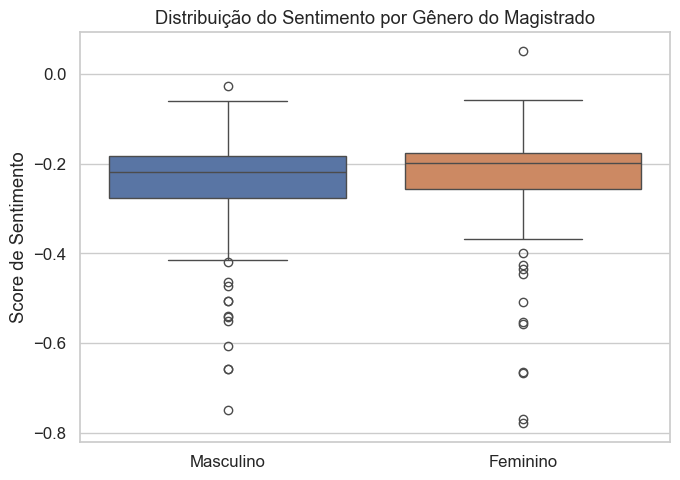

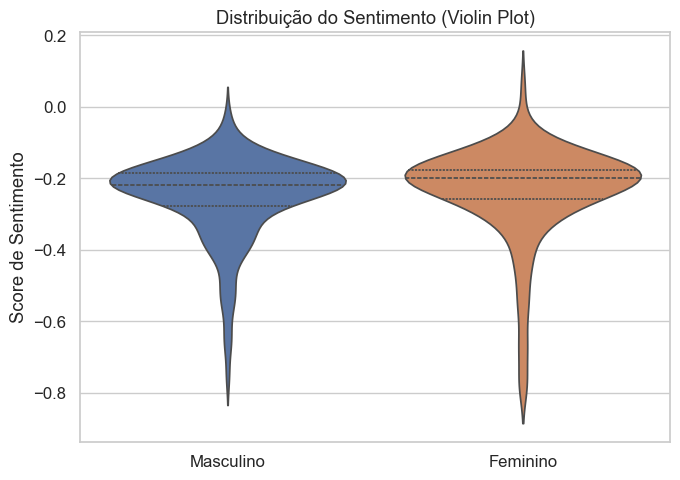

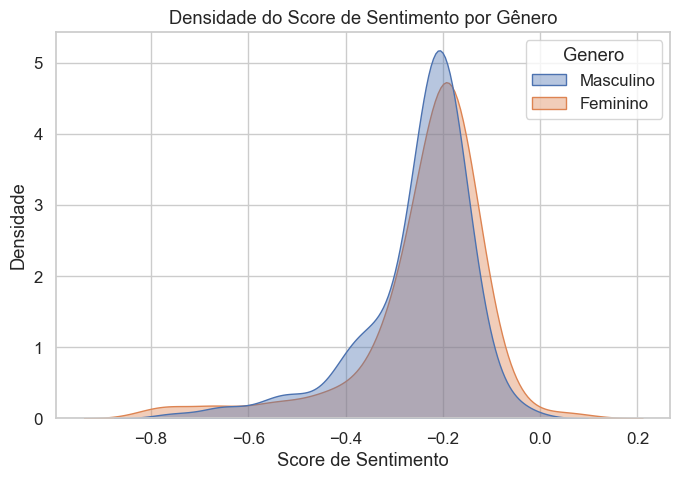

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Carregar corpus final
# =========================
CAMINHO = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\corpus_sentimento_tjce_dispositivo_com_sentimento.csv"

df = pd.read_csv(CAMINHO, sep=";", encoding="utf-8-sig")

# segurança metodológica
df = df[df["Genero"].isin(["Masculino", "Feminino"])]

sns.set(style="whitegrid", font_scale=1.1)

# =========================
# 1. Boxplot
# =========================
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Genero",
    y="Sent_Score",
    hue="Genero",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)
plt.title("Distribuição do Sentimento por Gênero do Magistrado")
plt.ylabel("Score de Sentimento")
plt.xlabel("")
plt.tight_layout()
plt.show()

# =========================
# 2. Violin plot
# =========================
plt.figure(figsize=(7, 5))
sns.violinplot(
    data=df,
    x="Genero",
    y="Sent_Score",
    hue="Genero",
    inner="quartile",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)
plt.title("Distribuição do Sentimento (Violin Plot)")
plt.ylabel("Score de Sentimento")
plt.xlabel("")
plt.tight_layout()
plt.show()

# =========================
# 3. Densidade (KDE)
# =========================
plt.figure(figsize=(7, 5))
sns.kdeplot(
    data=df,
    x="Sent_Score",
    hue="Genero",
    fill=True,
    common_norm=False,
    alpha=0.4,
    palette=["#4C72B0", "#DD8452"]
)
plt.title("Densidade do Score de Sentimento por Gênero")
plt.xlabel("Score de Sentimento")
plt.ylabel("Densidade")
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================
# Preparar dados
# =========================
CAMINHO = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Deep Learning\Trabalho Final\Kelsen\corpus_sentimento_tjce_dispositivo_com_sentimento.csv"

df = pd.read_csv(CAMINHO, sep=";", encoding="utf-8-sig")

# Mantém apenas masculino e feminino
df["Genero"] = df["Genero"].fillna("").astype(str).str.strip()
df = df[df["Genero"].isin(["Masculino", "Feminino"])].copy()

# Garante Sent_Score numérico e remove NaN
df["Sent_Score"] = pd.to_numeric(df["Sent_Score"], errors="coerce")
df = df.dropna(subset=["Sent_Score"]).copy()

# Codificação binária: Masculino=0 (baseline), Feminino=1
df["Genero_bin"] = df["Genero"].map({"Masculino": 0, "Feminino": 1}).astype(int)

# =========================
# Regressão (OLS via linregress)
# =========================
X = df["Genero_bin"].values
y = df["Sent_Score"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

print("Regressão linear simples (Sent_Score ~ Genero_bin):")
print(f"N total: {len(df)} | Masculino: {(df['Genero_bin']==0).sum()} | Feminino: {(df['Genero_bin']==1).sum()}")
print(f"Intercepto (Masculino): {intercept:.6f}")
print(f"Coeficiente (Feminino): {slope:.6f}  (diferença média vs masculino)")
print(f"Erro-padrão do coef.: {std_err:.6f}")
print(f"p-valor: {p_value:.6f}")
print(f"R²: {r_value**2:.8f}")

Regressão linear simples (Sent_Score ~ Genero_bin):
N total: 265 | Masculino: 160 | Feminino: 105
Intercepto (Masculino): -0.251294
Coeficiente (Feminino): 0.012390  (diferença média vs masculino)
Erro-padrão do coef.: 0.015408
p-valor: 0.422060
R²: 0.00245250


## Análise Gráfica e Regressão de Robustez

Como complemento aos testes estatísticos não paramétricos, foram realizadas análises gráficas e uma regressão linear simples com o objetivo de avaliar a robustez dos resultados e facilitar a interpretação substantiva das diferenças (ou ausência delas) entre os grupos analisados.

### Análise Gráfica

Foram construídos três tipos de visualizações — boxplot, violin plot e curvas de densidade (KDE) — comparando os escores de sentimento dos dispositivos das sentenças proferidas por magistrados do sexo masculino e feminino.

Os três gráficos convergem para o mesmo padrão empírico. As medianas e os intervalos interquartis são praticamente idênticos entre os grupos, e as distribuições apresentam elevada sobreposição ao longo de toda a escala de sentimento. Observa-se, em ambos os casos, uma assimetria negativa semelhante, característica esperada da linguagem decisória em sentenças penais, nas quais predominam construções formais, neutras e frequentemente associadas a sanções.

Essas evidências visuais reforçam os resultados obtidos pelo teste de Mann–Whitney U, indicando ausência de diferença sistemática no sentimento expresso nos dispositivos das sentenças entre magistrados do sexo masculino e feminino.

### Regressão Linear Simples (Análise de Robustez)

Como análise adicional de robustez, estimou-se uma regressão linear simples em que o escore contínuo de sentimento (Sent_Score) foi modelado como função do sexo do magistrado. A variável independente foi codificada de forma binária, adotando-se magistrados do sexo masculino como categoria de referência (0 = masculino; 1 = feminino).

A regressão foi estimada sobre o corpus final, composto por 265 sentenças válidas (160 proferidas por magistrados do sexo masculino e 105 por magistradas do sexo feminino).

Os resultados indicaram um coeficiente associado ao sexo feminino pequeno e positivo (β ≈ 0.012), com p-valor elevado (p ≈ 0.422) e coeficiente de determinação praticamente nulo (R² ≈ 0.0025). Esses valores indicam que o sexo do magistrado explica uma parcela desprezível da variação observada no sentimento dos dispositivos das sentenças.

### Síntese dos Resultados

Em conjunto, a análise gráfica, o teste não paramétrico de Mann–Whitney U e a regressão linear simples convergem para a mesma conclusão substantiva: **não há evidência estatisticamente significativa nem substantivamente relevante de diferença no sentimento das sentenças judiciais em função do sexo do magistrado** no corpus analisado.

Esses achados sugerem que, ao menos no contexto específico das sentenças de crimes contra a fauna no Tribunal de Justiça do Estado do Ceará, o dispositivo das decisões apresenta um padrão discursivo fortemente institucionalizado, pouco sensível a características individuais do julgador, como o sexo.
